# Radiografía comparativa de simulaciones desde `summary.xlsx` y `metadata.json`

Este notebook está pensado como un instrumento de lectura experimental. Su propósito no es fabricar un indicador nuevo, sino hacer visible qué ocurrió durante el entrenamiento y cómo ese comportamiento se relaciona con los parámetros de configuración que cambiaron entre simulaciones.

La lógica del flujo es incremental:

1. reconocer corridas, columnas y parámetros disponibles;
2. cargar solo las señales necesarias del `summary.xlsx`;
3. observar la evolución física del sistema;
4. observar la acción de control y las ganancias aprendidas;
5. auditar si la normalización y los componentes `L_*` son consistentes con la física;
6. revisar composición de recompensa y señales de aprendizaje;
7. cruzar los resultados con metadata para orientar el siguiente ajuste de parámetros.

La decisión final debe salir de la coherencia entre estas capas: una recompensa mayor no basta si el error físico, la saturación, las ganancias o los `L_*` cuentan una historia contradictoria.


In [1]:
from pathlib import Path
import json
import math
import os
import re
import warnings
from zipfile import ZipFile
from xml.etree.ElementTree import iterparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 200)

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})


## Funciones auxiliares

Las funciones de esta sección no fijan nombres de variables físicas ni controladores. Primero descubren columnas, variables, familias de señales y parámetros; después las secciones del análisis seleccionan qué usar a partir de esas opciones. Si una columna necesaria no existe, el notebook debe fallar de forma explícita y mostrar qué falta.


In [2]:
XLSX_NS = "{http://schemas.openxmlformats.org/spreadsheetml/2006/main}"
CELL_REF_RE = re.compile(r"([A-Z]+)([0-9]+)")
SUMMARY_STATS = ["mean", "std", "min", "p25", "p50", "p75", "max"]
GAIN_NAMES = ["kp", "ki", "kd"]


def find_project_root(start):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "results_history_CartPole").exists() and (candidate / "config").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del proyecto. Ajusta PROJECT_ROOT o ejecuta desde el repo.")


def require_path(path, label):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Falta {label}: {path}")
    return path


def require_columns(columns_or_df, required, context="DataFrame"):
    columns = list(columns_or_df.columns) if hasattr(columns_or_df, "columns") else list(columns_or_df)
    missing = [col for col in required if col not in columns]
    if missing:
        raise KeyError(f"Faltan columnas requeridas en {context}: {missing}")


def col_to_index(col_letters):
    value = 0
    for char in col_letters:
        value = value * 26 + ord(char) - 64
    return value - 1


def load_shared_strings(zf):
    if "xl/sharedStrings.xml" not in zf.namelist():
        return []
    values = []
    with zf.open("xl/sharedStrings.xml") as fh:
        for _, elem in iterparse(fh, events=("end",)):
            if elem.tag == XLSX_NS + "si":
                values.append("".join(node.text or "" for node in elem.iter(XLSX_NS + "t")))
                elem.clear()
    return values


def parse_cell_value(cell, shared_strings):
    cell_type = cell.attrib.get("t")
    if cell_type == "inlineStr":
        return "".join(node.text or "" for node in cell.iter(XLSX_NS + "t"))
    value_node = cell.find(XLSX_NS + "v")
    if value_node is None or value_node.text is None:
        return None
    raw = value_node.text
    if cell_type == "s":
        return shared_strings[int(raw)]
    if cell_type == "b":
        return bool(int(raw))
    try:
        return float(raw) if any(char in raw for char in ".eE") else int(raw)
    except ValueError:
        return raw


def row_to_indexed_values(row, shared_strings):
    values = {}
    for cell in row.findall(XLSX_NS + "c"):
        match = CELL_REF_RE.match(cell.attrib.get("r", ""))
        if match:
            values[col_to_index(match.group(1))] = parse_cell_value(cell, shared_strings)
    return values


def first_worksheet_path(zf):
    path = "xl/worksheets/sheet1.xml"
    if path not in zf.namelist():
        raise FileNotFoundError("El summary.xlsx no contiene xl/worksheets/sheet1.xml")
    return path


def read_xlsx_header(xlsx_path):
    xlsx_path = require_path(xlsx_path, "summary.xlsx")
    with ZipFile(xlsx_path) as zf:
        shared_strings = load_shared_strings(zf)
        with zf.open(first_worksheet_path(zf)) as fh:
            for _, row in iterparse(fh, events=("end",)):
                if row.tag == XLSX_NS + "row":
                    indexed = row_to_indexed_values(row, shared_strings)
                    if not indexed:
                        raise ValueError(f"No se encontró encabezado en {xlsx_path}")
                    return [indexed.get(i) for i in range(max(indexed) + 1)]
    raise ValueError(f"No se encontró ninguna fila en {xlsx_path}")


def read_xlsx_selected_columns(xlsx_path, selected_columns):
    xlsx_path = require_path(xlsx_path, "summary.xlsx")
    if not selected_columns:
        raise ValueError("selected_columns no puede estar vacío")
    with ZipFile(xlsx_path) as zf:
        shared_strings = load_shared_strings(zf)
        rows, header, selected_indices = [], None, None
        with zf.open(first_worksheet_path(zf)) as fh:
            for _, row in iterparse(fh, events=("end",)):
                if row.tag != XLSX_NS + "row":
                    continue
                indexed = row_to_indexed_values(row, shared_strings)
                if header is None:
                    header = [indexed.get(i) for i in range(max(indexed) + 1)]
                    require_columns(header, selected_columns, context=str(xlsx_path))
                    selected_indices = [header.index(col) for col in selected_columns]
                else:
                    rows.append([indexed.get(i) for i in selected_indices])
                row.clear()
    return pd.DataFrame(rows, columns=selected_columns)


def build_run_catalog(results_root, system_folder):
    system_dir = require_path(Path(results_root) / system_folder, "carpeta de sistema")
    rows = []
    for run_dir in sorted(path for path in system_dir.iterdir() if path.is_dir()):
        summary_path = run_dir / "summary.xlsx"
        metadata_path = run_dir / "metadata.json"
        if summary_path.exists() and metadata_path.exists():
            rows.append({
                "run_id": run_dir.name,
                "run_dir": run_dir,
                "summary_path": summary_path,
                "metadata_path": metadata_path,
                "summary_mb": round(summary_path.stat().st_size / 1024 / 1024, 2),
                "metadata_kb": round(metadata_path.stat().st_size / 1024, 2),
            })
    if not rows:
        raise FileNotFoundError(f"No hay corridas completas en {system_dir}")
    return pd.DataFrame(rows)


def select_run_catalog(catalog, mode, run_limit=None, explicit_run_ids=None):
    explicit_run_ids = explicit_run_ids or []
    options = ["all", "last_n", "explicit"]
    if mode not in options:
        raise ValueError(f"RUN_SELECTION_MODE debe estar en {options}")
    if mode == "all":
        selected = catalog.copy()
    elif mode == "last_n":
        if run_limit is None or int(run_limit) <= 0:
            raise ValueError("RUN_LIMIT debe ser positivo cuando RUN_SELECTION_MODE='last_n'")
        selected = catalog.tail(int(run_limit)).copy()
    else:
        missing = sorted(set(explicit_run_ids) - set(catalog["run_id"]))
        if missing:
            raise ValueError(f"Corridas inexistentes en EXPLICIT_RUN_IDS: {missing}")
        selected = catalog[catalog["run_id"].isin(explicit_run_ids)].copy()
    selected = selected.sort_values("run_id").reset_index(drop=True)
    if selected.empty:
        raise ValueError("La selección de corridas quedó vacía")
    return selected


def scalarish(value):
    return isinstance(value, (str, int, float, bool)) or value is None


def flatten_metadata(obj, prefix=""):
    if isinstance(obj, dict):
        for key, value in obj.items():
            yield from flatten_metadata(value, f"{prefix}.{key}" if prefix else str(key))
    elif isinstance(obj, list):
        if all(scalarish(item) for item in obj):
            yield prefix, tuple(obj)
            if len(obj) <= 8:
                for idx, item in enumerate(obj):
                    yield f"{prefix}[{idx}]", item
        else:
            for idx, item in enumerate(obj):
                yield from flatten_metadata(item, f"{prefix}[{idx}]")
    else:
        yield prefix, obj


def load_metadata_table(catalog):
    rows = []
    for row in catalog.itertuples(index=False):
        with Path(row.metadata_path).open("r", encoding="utf-8") as fh:
            metadata = json.load(fh)
        flat = {key: value for key, value in flatten_metadata(metadata)}
        flat["run_id"] = row.run_id
        rows.append(flat)
    return pd.DataFrame(rows).set_index("run_id", drop=False)


def coerce_numeric_series(series):
    converted = series.map(lambda value: int(value) if isinstance(value, (bool, np.bool_)) else value)
    return pd.to_numeric(converted, errors="coerce")


def metadata_family(path):
    rules = [
        ("principal_features", ["principal_reward.weighted_exponential_params.features"]),
        ("principal_gates", ["principal_reward.weighted_exponential_params.feature_gates"]),
        ("coordination", ["coordination_reward"]),
        ("normalization", ["metric_processing.normalization.params"]),
        ("agent_learning", ["agent_base.params"]),
        ("agent_actions", ["agent_config.actions"]),
        ("controller", ["controller_base"]),
        ("physical_system", ["dynamic_system"]),
        ("simulation", ["simulation"]),
    ]
    for family, tokens in rules:
        if any(token in path for token in tokens):
            return family
    return "other"


def compact_preview(values, max_items=6, max_chars=220):
    text = ", ".join(values[:max_items])
    return text[:max_chars] + "..." if len(text) > max_chars else text


def short_metadata_label(path):
    replacements = [
        ("config_main.reward_base.reward_calculation.principal_reward.weighted_exponential_params.features.", "principal."),
        ("config_main.reward_base.reward_calculation.principal_reward.weighted_exponential_params.feature_gates.", "gate."),
        ("config_main.reward_base.reward_calculation.coordination_reward.", "coord."),
        ("config_main.reward_base.reward_calculation.metric_processing.normalization.params.", "norm."),
        ("config_main.agent_base.params.", "agent."),
        ("config_main.agent_base.agent_config.actions.actions_values.", "action."),
        ("config_main.dynamic_system.", "system."),
        ("config_main.controller_base.", "controller."),
        ("config_main.simulation.", "simulation."),
        ("config_main.", ""),
    ]
    label = path
    for old, new in replacements:
        label = label.replace(old, new)
    return label


def metadata_inventory(metadata_table):
    rows = []
    for col in metadata_table.columns:
        if col == "run_id":
            continue
        series = metadata_table[col].dropna()
        if series.empty:
            continue
        as_text = series.map(lambda value: json.dumps(value, ensure_ascii=False, sort_keys=True) if isinstance(value, (tuple, list, dict)) else str(value))
        numeric = coerce_numeric_series(series)
        preview_values = as_text.drop_duplicates().astype(str).tolist()
        rows.append({
            "param_path": col,
            "short_label": short_metadata_label(col),
            "family": metadata_family(col),
            "n_unique": int(as_text.nunique()),
            "is_numeric": bool(numeric.notna().all()),
            "values_preview": compact_preview(preview_values),
        })
    return pd.DataFrame(rows).sort_values(["family", "n_unique", "param_path"], ascending=[True, False, True]).reset_index(drop=True)


def split_stat_column(column):
    for stat in SUMMARY_STATS:
        suffix = f"_{stat}"
        if column.endswith(suffix):
            return column[: -len(suffix)], stat
    return column, None


def infer_target_variables(columns):
    variables = set()
    for col in columns:
        for gain in GAIN_NAMES:
            prefix = f"final_{gain}_"
            if str(col).startswith(prefix):
                variables.add(str(col)[len(prefix):])
    return sorted(variables)


def infer_state_variables(columns):
    variables = set()
    for col in columns:
        if str(col).startswith("final_") and str(col).endswith("_raw"):
            variables.add(str(col)[len("final_"):-len("_raw")])
        if str(col).startswith("final_") and str(col).endswith("_normalized"):
            variables.add(str(col)[len("final_"):-len("_normalized")])
    for col in columns:
        base, stat = split_stat_column(str(col))
        if stat and (base.endswith("_raw") or base.endswith("_norm")):
            variables.add(base.rsplit("_", 1)[0])
    return sorted(variables)


def infer_variable_from_base(base, variables):
    for var in sorted(variables, key=len, reverse=True):
        if base == var or base.endswith("_" + var) or base.startswith(var + "_") or f"_{var}_" in base:
            return var
    return None


def classify_summary_column(column, target_vars, state_vars):
    col = str(column)
    base, stat = split_stat_column(col)
    all_vars = sorted(set(target_vars) | set(state_vars))
    variable = infer_variable_from_base(base, all_vars)

    if col in ["episode_id", "epsilon", "learning_rate", "total_agent_decisions", "final_t_sec", "total_reward", "performance", "end_termination_reason"]:
        return "outcome_training", base, stat, variable
    if any(col.startswith(f"final_{gain}_") for gain in GAIN_NAMES):
        return "controller_gain", base, stat, variable
    if col.startswith("final_"):
        return "physical_final_state", base, stat, variable
    if base.startswith("td_error_") or base.startswith("q_value_"):
        return "learning_signal", base, stat, variable
    if base.startswith("principal_gate_"):
        return "principal_gates", base, stat, variable
    if base.startswith("principal_contribution_") or base.startswith("L_"):
        return "loss_components", base, stat, variable
    if base.startswith("coordination_"):
        return "coordination", base, stat, variable
    if "reward" in base or base.startswith("extra_"):
        return "reward_components", base, stat, variable
    if base.startswith(("error_", "delta_error_", "derivative_error_", "integral_error_")) or base.endswith("_rms"):
        return "error_dynamics", base, stat, variable
    if any(token in base for token in ["control_action", "u_eff", "u_total", "cart_force", "u_alloc", "u_conflict", "delta_u", "saturation"]):
        return "control_effort", base, stat, variable
    if variable in state_vars or base.endswith("_raw") or base.endswith("_norm"):
        return "physical_state", base, stat, variable
    return "other", base, stat, variable


def build_summary_dictionary(headers_by_run):
    all_columns = sorted(set().union(*[set(cols) for cols in headers_by_run.values()]))
    target_vars = infer_target_variables(all_columns)
    state_vars = infer_state_variables(all_columns)
    rows = []
    for col in all_columns:
        family, base, stat, variable = classify_summary_column(col, target_vars, state_vars)
        rows.append({
            "column": col,
            "base_metric": base,
            "stat": stat,
            "family": family,
            "variable": variable,
            "n_runs_available": sum(col in cols for cols in headers_by_run.values()),
        })
    dictionary = pd.DataFrame(rows)
    return dictionary, target_vars, state_vars


def metric_options(dictionary, families=None, variables=None, stats=None):
    out = dictionary.copy()
    if families is not None:
        out = out[out["family"].isin(families)]
    if variables is not None:
        out = out[out["variable"].isin(variables) | out["variable"].isna()]
    if stats is not None:
        out = out[out["stat"].isin(stats) | out["stat"].isna()]
    return out.sort_values(["family", "variable", "base_metric", "stat", "column"]).reset_index(drop=True)


def choose_base_metrics(dictionary, families, variables=None, preferred_terms=None, max_metrics=None):
    options = metric_options(dictionary, families=families, variables=variables)
    bases = options["base_metric"].dropna().drop_duplicates().tolist()
    if preferred_terms:
        preferred = [base for base in bases if any(term in base for term in preferred_terms)]
        bases = preferred or bases
    if max_metrics is not None:
        bases = bases[:max_metrics]
    return bases


def columns_from_bases(dictionary, base_metrics, stats=None, include_unstat=True):
    subset = dictionary[dictionary["base_metric"].isin(base_metrics)].copy()
    if stats is not None:
        subset = subset[subset["stat"].isin(stats) | (subset["stat"].isna() if include_unstat else False)]
    return subset["column"].drop_duplicates().tolist()


def build_required_summary_columns(dictionary, families_to_load, variables, stats_to_load, extra_base_metrics=None):
    core = ["episode_id", "epsilon", "learning_rate", "total_agent_decisions", "final_t_sec", "total_reward", "performance", "end_termination_reason"]
    selected = dictionary[dictionary["column"].isin(core)].copy()
    selected = pd.concat([
        selected,
        metric_options(dictionary, families=families_to_load, variables=variables, stats=stats_to_load),
    ], ignore_index=True)
    if extra_base_metrics:
        selected = pd.concat([selected, dictionary[dictionary["base_metric"].isin(extra_base_metrics)]], ignore_index=True)
    return selected["column"].drop_duplicates().tolist()


def summary_contract(headers_by_run, required_columns):
    rows = []
    for run_id, columns in headers_by_run.items():
        missing = [col for col in required_columns if col not in columns]
        rows.append({
            "run_id": run_id,
            "n_columns_total": len(columns),
            "n_required_available": len(required_columns) - len(missing),
            "n_required_missing": len(missing),
            "missing_required_preview": missing[:12],
        })
    return pd.DataFrame(rows)


def cache_path_for(cache_dir, run_id, cache_format):
    suffix = "parquet" if cache_format == "parquet" else "csv"
    return Path(cache_dir) / f"{run_id}_summary_selected.{suffix}"


def read_cache(path, cache_format):
    return pd.read_parquet(path) if cache_format == "parquet" else pd.read_csv(path)


def write_cache(df, path, cache_format):
    path.parent.mkdir(parents=True, exist_ok=True)
    if cache_format == "parquet":
        df.to_parquet(path, index=False)
    else:
        df.to_csv(path, index=False)


def load_summary_dataset(catalog, headers_by_run, required_columns, cache_dir, cache_format="csv", rebuild_cache=False):
    if cache_format not in ["csv", "parquet"]:
        raise ValueError("cache_format debe ser 'csv' o 'parquet'")
    frames, manifest = [], []
    for row in catalog.itertuples(index=False):
        run_id = row.run_id
        available = [col for col in required_columns if col in headers_by_run[run_id]]
        require_columns(available, ["episode_id", "total_reward", "performance", "final_t_sec", "end_termination_reason"], context=run_id)
        cache_path = cache_path_for(cache_dir, run_id, cache_format)
        use_cache = cache_path.exists() and not rebuild_cache
        if use_cache:
            df = read_cache(cache_path, cache_format)
            if [col for col in available if col not in df.columns]:
                use_cache = False
        if not use_cache:
            df = read_xlsx_selected_columns(row.summary_path, available)
            write_cache(df, cache_path, cache_format)
        df = pd.concat(
            [
                df.reset_index(drop=True),
                pd.DataFrame({"run_id": run_id, "episode_order": np.arange(len(df))}),
            ],
            axis=1,
        ).copy()
        frames.append(df)
        manifest.append({
            "run_id": run_id,
            "source": "cache" if use_cache else "summary.xlsx",
            "rows": len(df),
            "loaded_columns": len(available),
            "cache_path": str(cache_path),
        })
    return pd.concat(frames, ignore_index=True, sort=False), pd.DataFrame(manifest)


def add_training_windows(df, window_size):
    if window_size <= 0:
        raise ValueError("window_size debe ser positivo")
    out = df.copy()
    out["episode_window"] = (out["episode_order"] // window_size) * window_size
    return out


def build_window_table(df, metric_columns, window_size):
    require_columns(df, ["run_id", "episode_order", "end_termination_reason"], context="summary_df")
    work = add_training_windows(df, window_size)
    numeric_data = {}
    for col in metric_columns:
        if col not in work.columns or col == "end_termination_reason":
            continue
        converted = pd.to_numeric(work[col], errors="coerce")
        if converted.notna().any():
            numeric_data[col] = converted
    numeric_cols = list(numeric_data)
    numeric_work = pd.concat([work[["run_id", "episode_window"]].reset_index(drop=True), pd.DataFrame(numeric_data)], axis=1)
    agg = {col: (col, "mean") for col in numeric_cols}
    grouped = numeric_work.groupby(["run_id", "episode_window"], as_index=False).agg(**agg)
    outcome = work.groupby(["run_id", "episode_window"])["end_termination_reason"].agg(
        limit_rate=lambda s: (s.astype(str) == "limit_exceeded").mean(),
        time_limit_rate=lambda s: (s.astype(str) == "time_limit").mean(),
        success_rate=lambda s: (s.astype(str) == "stabilization_success").mean(),
    ).reset_index()
    return grouped.merge(outcome, on=["run_id", "episode_window"], how="left")


def select_training_stages(df, stage_config):
    rows = []
    for run_id, run_df in df.groupby("run_id", sort=False):
        n = len(run_df)
        ordered = run_df.sort_values("episode_order")
        for label, start_frac, end_frac in stage_config:
            start = int(np.floor(start_frac * n))
            end = int(np.floor(end_frac * n))
            stage = ordered.iloc[start:max(start + 1, end)].copy()
            stage["training_stage"] = label
            rows.append(stage)
    return pd.concat(rows, ignore_index=True, sort=False)


def summarize_by_run_stage(stage_df, metric_columns):
    rows = []
    for (run_id, stage), group in stage_df.groupby(["run_id", "training_stage"], sort=False):
        row = {"run_id": run_id, "training_stage": stage, "episodes": len(group)}
        term = group["end_termination_reason"].astype(str)
        row["limit_rate"] = (term == "limit_exceeded").mean()
        row["time_limit_rate"] = (term == "time_limit").mean()
        row["success_rate"] = (term == "stabilization_success").mean()
        for col in metric_columns:
            if col in group.columns and col != "end_termination_reason":
                converted = pd.to_numeric(group[col], errors="coerce")
                if converted.notna().any():
                    row[col] = converted.mean()
        rows.append(row)
    return pd.DataFrame(rows)


def final_stage_table(stage_summary, final_stage_label):
    final = stage_summary[stage_summary["training_stage"] == final_stage_label].copy()
    if final.empty:
        raise ValueError(f"No hay filas para la etapa final {final_stage_label}")
    return final.reset_index(drop=True)


def normalize_for_heatmap(df, columns):
    numeric = df[columns].apply(pd.to_numeric, errors="coerce")
    scaled = numeric.copy()
    for col in numeric.columns:
        values = numeric[col]
        if values.notna().sum() == 0 or math.isclose(float(values.min()), float(values.max())):
            scaled[col] = 0.0
        else:
            scaled[col] = (values - values.mean()) / values.std(ddof=0)
    return scaled


def corr_table(left_df, right_df, left_key, right_key, left_columns, right_columns, method="spearman"):
    merged = left_df[[left_key] + left_columns].merge(right_df[[right_key] + right_columns], left_on=left_key, right_on=right_key, how="inner")
    rows = []
    for lcol in left_columns:
        for rcol in right_columns:
            corr = merged[[lcol, rcol]].corr(method=method).iloc[0, 1]
            rows.append({"parameter": lcol, "metric": rcol, "correlation": corr})
    return pd.DataFrame(rows)


def parameter_value_table(metadata_table, inventory, families, only_variant=True, only_numeric=True, max_parameters=24):
    subset = inventory.copy()
    if families:
        subset = subset[subset["family"].isin(families)]
    if only_variant:
        subset = subset[subset["n_unique"] > 1]
    if only_numeric:
        subset = subset[subset["is_numeric"]]
    subset = subset.sort_values(["family", "n_unique", "param_path"], ascending=[True, False, True]).head(max_parameters)
    value_columns = {"run_id": metadata_table["run_id"]}
    used_labels = set()
    label_map = {}
    for path in subset["param_path"]:
        label = short_metadata_label(path)
        original = label
        counter = 2
        while label in used_labels:
            label = f"{original} [{counter}]"
            counter += 1
        used_labels.add(label)
        label_map[path] = label
        value_columns[label] = coerce_numeric_series(metadata_table[path])
    values = pd.DataFrame(value_columns)
    return values.reset_index(drop=True), subset.assign(selected_label=subset["param_path"].map(label_map)).reset_index(drop=True)


def minmax_by_group(series):
    min_value = series.min()
    max_value = series.max()
    if pd.isna(min_value) or pd.isna(max_value) or math.isclose(float(min_value), float(max_value)):
        return pd.Series(0.5, index=series.index)
    return (series - min_value) / (max_value - min_value)


def ordered_run_ids(final_profile, order_metric=None, ascending=False):
    if order_metric and order_metric in final_profile.columns:
        return final_profile.sort_values(order_metric, ascending=ascending)["run_id"].tolist()
    return final_profile["run_id"].tolist()


def plot_window_lines(window_table, metrics, run_ids=None, title=None, ylabels=None):
    run_ids = run_ids or window_table["run_id"].drop_duplicates().tolist()
    metrics = [m for m in metrics if m in window_table.columns]
    if not metrics:
        raise KeyError("No hay métricas disponibles para plot_window_lines")
    n = len(metrics)
    fig, axes = plt.subplots(n, 1, figsize=(13, 3.4 * n), sharex=True)
    axes = np.atleast_1d(axes)
    data = window_table[window_table["run_id"].isin(run_ids)]
    for ax, metric in zip(axes, metrics):
        sns.lineplot(data=data, x="episode_window", y=metric, hue="run_id", marker="o", linewidth=1.4, ax=ax, legend=False)
        ax.set_ylabel(ylabels.get(metric, metric) if ylabels else metric)
        ax.set_xlabel("episodio inicial de la ventana")
        ax.set_title(metric)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title="corrida", bbox_to_anchor=(1.01, 0.98), loc="upper left")
    if title:
        fig.suptitle(title, y=1.01, fontsize=15)
    fig.tight_layout()
    return fig


def plot_stage_distribution(stage_df, metric, run_order=None, title=None):
    require_columns(stage_df, ["run_id", "training_stage", metric], context="stage_df")
    order = run_order or sorted(stage_df["run_id"].unique())
    fig, ax = plt.subplots(figsize=(max(12, 0.55 * len(order)), 6))
    sns.boxplot(data=stage_df, x="run_id", y=metric, hue="training_stage", order=order, ax=ax, showfliers=False)
    ax.set_title(title or f"Distribución por etapa: {metric}")
    ax.set_xlabel("corrida")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=65)
    ax.legend(title="etapa", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.tight_layout()
    return fig


def plot_metric_heatmap(profile, metric_columns, run_order=None, title=None, standardize=True):
    metric_columns = [col for col in metric_columns if col in profile.columns]
    if not metric_columns:
        raise KeyError("No hay columnas disponibles para plot_metric_heatmap")
    data = profile.set_index("run_id").loc[run_order or profile["run_id"].tolist(), metric_columns]
    numeric = data.apply(pd.to_numeric, errors="coerce")
    shown = normalize_for_heatmap(numeric.reset_index(), metric_columns).set_index(numeric.index) if standardize else numeric
    fig, ax = plt.subplots(figsize=(max(10, 0.7 * len(metric_columns)), max(5, 0.42 * len(shown))))
    sns.heatmap(shown, cmap="vlag", center=0 if standardize else None, annot=numeric, fmt=".3g", linewidths=0.5, ax=ax)
    ax.set_title(title or "Mapa comparativo por corrida")
    ax.set_xlabel("indicador")
    ax.set_ylabel("corrida")
    fig.tight_layout()
    return fig


def plot_parameter_metric_heatmap(correlation_df, max_parameters=12, title=None):
    data = correlation_df.dropna(subset=["correlation"]).copy()
    if data.empty:
        raise ValueError("No hay correlaciones válidas para graficar")
    strength = data.assign(abs_corr=data["correlation"].abs()).groupby("parameter")["abs_corr"].max().sort_values(ascending=False)
    selected = strength.head(max_parameters).index.tolist()
    matrix = data[data["parameter"].isin(selected)].pivot(index="parameter", columns="metric", values="correlation")
    fig, ax = plt.subplots(figsize=(max(11, 0.9 * len(matrix.columns)), max(5, 0.42 * len(matrix))))
    sns.heatmap(matrix, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.5, ax=ax)
    ax.set_title(title or "Relación monotónica entre parámetros y resultados")
    ax.set_xlabel("indicador de summary")
    ax.set_ylabel("parámetro de metadata")
    fig.tight_layout()
    return fig


def plot_parameter_scatter_grid(profile, parameter_values, parameters, metrics):
    merged = profile.merge(parameter_values, on="run_id", how="left")
    parameters = [p for p in parameters if p in merged.columns]
    metrics = [m for m in metrics if m in merged.columns]
    if not parameters or not metrics:
        raise KeyError("Faltan parámetros o métricas para la grilla de dispersión")
    fig, axes = plt.subplots(len(metrics), len(parameters), figsize=(5.0 * len(parameters), 3.7 * len(metrics)), squeeze=False)
    for i, metric in enumerate(metrics):
        for j, param in enumerate(parameters):
            ax = axes[i, j]
            sns.regplot(data=merged, x=param, y=metric, ax=ax, scatter_kws={"s": 65, "alpha": 0.85, "edgecolor": "black"}, line_kws={"color": "#333333"})
            for _, row in merged.iterrows():
                ax.text(row[param], row[metric], row["run_id"], fontsize=7, alpha=0.72)
            ax.set_title(f"{metric} vs {param}")
    fig.tight_layout()
    return fig


def export_tables(output_dir, tables, excel_name):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    xlsx_path = output_dir / excel_name
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        for sheet_name, df in tables.items():
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)
            df.to_csv(output_dir / f"{sheet_name}.csv", index=False)
    return xlsx_path


## 1. Universo de corridas y contrato de lectura

**Propósito.** Identificar qué simulaciones pueden compararse y decidir el alcance del análisis. Esta sección no interpreta resultados: solo deja claro el universo disponible, la selección activa y el costo aproximado de lectura.

**Qué debe revisar el usuario.**

- Si la corrida que quiere comparar aparece en `run_catalog`.
- Si conviene analizar todas las corridas o partir con las últimas `n`.
- Si el primer pase desde Excel tarda, el cache posterior debe aparecer como `source = cache`.


In [3]:
# ----------------------------
# Configuración local de sección 1
# ----------------------------
PROJECT_ROOT = find_project_root(Path.cwd())
RESULTS_ROOT = PROJECT_ROOT / "results_history_CartPole"

available_system_folders = sorted(path.name for path in RESULTS_ROOT.iterdir() if path.is_dir())
display(pd.DataFrame({"available_system_folder": available_system_folders}))

SYSTEM_FOLDER = "cart_pole"       # opciones: ver available_system_folder
RUN_SELECTION_MODE = "explicit"        # opciones: "all", "last_n", "explicit"
RUN_LIMIT = None                  # entero positivo si RUN_SELECTION_MODE = "last_n"
EXPLICIT_RUN_IDS = ['20260506_1004_se acerca', '20260507_2246']             # lista de run_id si RUN_SELECTION_MODE = "explicit"

if os.environ.get("RL_SUMMARY_ANALYSIS_RUN_LIMIT"):
    RUN_SELECTION_MODE = "last_n"
    RUN_LIMIT = int(os.environ["RL_SUMMARY_ANALYSIS_RUN_LIMIT"])

run_catalog = build_run_catalog(RESULTS_ROOT, SYSTEM_FOLDER)
selected_catalog = select_run_catalog(run_catalog, RUN_SELECTION_MODE, RUN_LIMIT, EXPLICIT_RUN_IDS)

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Corridas disponibles: {len(run_catalog)} | corridas seleccionadas: {len(selected_catalog)}")
display(run_catalog[["run_id", "summary_mb", "metadata_kb"]])
display(selected_catalog[["run_id", "summary_mb", "metadata_kb"]])


,available_system_folder
0,cart_pole


Proyecto: C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5_SimpleSystemSimulator
Corridas disponibles: 14 | corridas seleccionadas: 2


,run_id,summary_mb,metadata_kb
0,20260503_0509,30.92,46.05
1,20260503_1200,30.86,46.04
2,20260504_0115,31.04,46.03
3,20260504_1906,31.08,46.03
4,20260505_0404,31.07,46.03
5,20260505_1001,31.06,46.03
6,20260505_1926,30.86,46.03
7,20260506_0356,30.61,46.03
8,20260506_1004_se acerca,31.14,46.03
9,20260507_0010_normal_gate,29.78,46.00


,run_id,summary_mb,metadata_kb
0,20260506_1004_se acerca,31.14,46.03
1,20260507_2246,30.34,46.04


## 2. Diccionario de señales y parámetros disponibles

**Propósito.** Convertir el Excel y la metadata en un mapa de posibilidades antes de cargar datos pesados. Aquí se descubren variables físicas, variables controladas, familias de columnas, estadísticas disponibles y parámetros de configuración que cambian entre corridas.

**Qué debe identificar.**

- `target_variable_options`: variables con ganancias PID aprendidas. Normalmente son los lazos que reciben agentes.
- `state_variable_options`: variables físicas observadas al final o resumidas por episodio.
- `summary_family`: familias de señales que luego pueden seleccionarse para análisis.
- `metadata_family`: grupos de parámetros modificables. Para tuning de reward suelen importar `principal_features`, `principal_gates`, `coordination` y `normalization`.


In [4]:
# ----------------------------
# Configuración local de sección 2
# ----------------------------
headers_by_run = {row.run_id: read_xlsx_header(row.summary_path) for row in selected_catalog.itertuples(index=False)}
summary_dictionary, target_variable_options, state_variable_options = build_summary_dictionary(headers_by_run)
metadata_table = load_metadata_table(selected_catalog)
metadata_dict = metadata_inventory(metadata_table)

summary_family_inventory = (
    summary_dictionary
    .groupby("family", as_index=False)
    .agg(
        n_columns=("column", "nunique"),
        n_base_metrics=("base_metric", "nunique"),
        variables=("variable", lambda s: ", ".join(sorted(v for v in s.dropna().unique()))),
        stats=("stat", lambda s: ", ".join(sorted(v for v in s.dropna().unique()))),
    )
    .sort_values("family")
)
metadata_family_inventory = (
    metadata_dict
    .groupby("family", as_index=False)
    .agg(
        n_parameters=("param_path", "count"),
        n_variant=("n_unique", lambda s: int((s > 1).sum())),
        n_numeric_variant=("is_numeric", lambda s: int(s.sum())),
    )
    .sort_values("family")
)

display(pd.DataFrame({"target_variable_options": target_variable_options}))
display(pd.DataFrame({"state_variable_options": state_variable_options}))
display(summary_family_inventory)
display(metadata_family_inventory)
display(metadata_dict[metadata_dict["n_unique"] > 1][["family", "short_label", "n_unique", "is_numeric", "values_preview", "param_path"]].head(60))


,target_variable_options
0,cart_position
1,pendulum_angle


,state_variable_options
0,cart_position
1,cart_velocity
2,pendulum_angle
3,pendulum_velocity


,family,n_columns,n_base_metrics,variables,stats
0,control_effort,70,10,"cart_position, pendulum_angle","max, mean, min, p25, p50, p75, std"
1,controller_gain,6,6,"cart_position, pendulum_angle",
2,coordination,56,8,"cart_position, pendulum_angle","max, mean, min, p25, p50, p75, std"
3,error_dynamics,98,14,"cart_position, pendulum_angle","max, mean, min, p25, p50, p75, std"
4,learning_signal,84,12,"cart_position, pendulum_angle","max, mean, min, p25, p50, p75, std"
5,loss_components,98,14,"cart_position, pendulum_angle","max, mean, min, p25, p50, p75, std"
6,outcome_training,8,8,,
7,physical_state,56,8,"cart_position, cart_velocity, pendulum_angle, ...","max, mean, min, p25, p50, p75, std"
8,principal_gates,28,4,"cart_position, pendulum_angle","max, mean, min, p25, p50, p75, std"
9,reward_components,63,9,"cart_position, pendulum_angle","max, mean, min, p25, p50, p75, std"


,family,n_parameters,n_variant,n_numeric_variant
0,agent_actions,11,0,7
1,agent_learning,10,0,9
2,controller,29,0,17
3,coordination,22,6,11
4,normalization,40,9,20
5,other,745,1,437
6,physical_system,53,0,37
7,principal_features,12,4,12
8,principal_gates,35,11,29
9,simulation,4,0,4


,family,short_label,n_unique,is_numeric,values_preview,param_path
50,coordination,coord.global_weight,2,True,"16, 8",config_main.reward_base.reward_calculation.coo...
51,coordination,coord.potential_weights.L_e.cart_position,2,True,"1.0, 1.5",config_main.reward_base.reward_calculation.coo...
52,coordination,coord.potential_weights.L_e.pendulum_angle,2,True,"0.5, 0.4",config_main.reward_base.reward_calculation.coo...
53,coordination,coord.potential_weights.L_edot.cart_position,2,True,"0.5, 0.8",config_main.reward_base.reward_calculation.coo...
54,coordination,coord.potential_weights.L_edot.pendulum_angle,2,True,"0.3, 0.2",config_main.reward_base.reward_calculation.coo...
55,coordination,coord.progress_clip_max,2,True,"0.04, 0.02",config_main.reward_base.reward_calculation.coo...
72,normalization,norm.cart_position.I.range,2,False,"[-2.0, 2.0], [-0.7, 0.7]",config_main.reward_base.reward_calculation.met...
73,normalization,norm.cart_position.I.range[0],2,True,"-2.0, -0.7",config_main.reward_base.reward_calculation.met...
74,normalization,norm.cart_position.I.range[1],2,True,"2.0, 0.7",config_main.reward_base.reward_calculation.met...
75,normalization,norm.cart_position.e.range,2,False,"[-1.0, 1.0], [-0.3, 0.3]",config_main.reward_base.reward_calculation.met...


## 3. Selección explícita de señales y carga eficiente

**Propósito.** Definir qué familias de señales se leerán desde `summary.xlsx`. El notebook muestra opciones antes; aquí el usuario decide el subconjunto. La lectura se hace por columnas seleccionadas y queda cacheada para acelerar iteraciones.

**Criterio de selección.**

- Para radiografía física: `physical_state` y `error_dynamics`.
- Para control: `controller_gain` y `control_effort`.
- Para normalización y reward: `loss_components`, `principal_gates`, `reward_components`, `coordination`.
- Para aprendizaje: `learning_signal`.

No es necesario cargar todo el Excel si la pregunta se concentra en una parte del pipeline.


In [5]:
# ----------------------------
# Configuración local de sección 3
# ----------------------------
ANALYSIS_TARGET_VARIABLES = target_variable_options     # opciones: ver target_variable_options
ANALYSIS_STATE_VARIABLES = state_variable_options       # opciones: ver state_variable_options
SUMMARY_FAMILIES_TO_LOAD = [
    "outcome_training",
    "physical_final_state",
    "physical_state",
    "error_dynamics",
    "controller_gain",
    "control_effort",
    "loss_components",
    "principal_gates",
    "reward_components",
    "coordination",
    "learning_signal",
]
SUMMARY_STATS_TO_LOAD = ["p25", "p75"]  # opciones: mean, std, min, p25, p50, p75, max
WINDOW_SIZE_EPISODES = 250                                    # opciones útiles: 100, 250, 500, 1000
TRAINING_STAGES = [
    ("inicio", 0.00, 0.20),
    ("medio", 0.40, 0.60),
    ("final", 0.80, 1.00),
]

CACHE_DIR = PROJECT_ROOT / "analysis" / "_summary_reward_metadata_cache"
CACHE_FORMAT = "csv"                 # opciones: "csv", "parquet"
REBUILD_CACHE = False                 # True fuerza volver a leer summary.xlsx

if os.environ.get("RL_SUMMARY_ANALYSIS_REBUILD_CACHE"):
    REBUILD_CACHE = os.environ["RL_SUMMARY_ANALYSIS_REBUILD_CACHE"].lower() == "true"

required_summary_columns = build_required_summary_columns(
    dictionary=summary_dictionary,
    families_to_load=SUMMARY_FAMILIES_TO_LOAD,
    variables=sorted(set(ANALYSIS_TARGET_VARIABLES) | set(ANALYSIS_STATE_VARIABLES)),
    stats_to_load=SUMMARY_STATS_TO_LOAD,
)
contract_table = summary_contract(headers_by_run, required_summary_columns)
display(contract_table)

summary_df, load_manifest = load_summary_dataset(
    selected_catalog,
    headers_by_run,
    required_summary_columns,
    CACHE_DIR,
    cache_format=CACHE_FORMAT,
    rebuild_cache=REBUILD_CACHE,
)

loaded_metric_columns = [col for col in summary_df.columns if col not in ["run_id", "episode_order"]]
window_table = build_window_table(summary_df, loaded_metric_columns, WINDOW_SIZE_EPISODES)
stage_df = select_training_stages(summary_df, TRAINING_STAGES)
stage_summary = summarize_by_run_stage(stage_df, loaded_metric_columns)
final_profile = final_stage_table(stage_summary, "final")

print(f"Episodios cargados: {len(summary_df):,}")
print(f"Columnas cargadas: {len(summary_df.columns):,}")
display(load_manifest)
preview_columns = [col for col in [
    "run_id", "episode_order", "episode_id", "epsilon", "learning_rate",
    "final_t_sec", "total_reward", "performance", "end_termination_reason",
] if col in summary_df.columns]
preview_columns += [col for col in summary_df.columns if col not in preview_columns][:12]
display(summary_df[preview_columns].head(3))


,run_id,n_columns_total,n_required_available,n_required_missing,missing_required_preview
0,20260506_1004_se acerca,567,172,0,[]
1,20260507_2246,567,172,0,[]


Episodios cargados: 10,000
Columnas cargadas: 174


,run_id,source,rows,loaded_columns,cache_path
0,20260506_1004_se acerca,summary.xlsx,5000,172,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...
1,20260507_2246,summary.xlsx,5000,172,C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5...


,run_id,episode_order,episode_id,epsilon,learning_rate,final_t_sec,total_reward,performance,end_termination_reason,total_agent_decisions,control_action_cart_position_p25,control_action_cart_position_p75,delta_u_eff_cart_position_p25,delta_u_eff_cart_position_p75,saturation_proportion_cart_position_p25,saturation_proportion_cart_position_p75,u_eff_cart_position_p25,u_eff_cart_position_p75,control_action_pendulum_angle_p25,control_action_pendulum_angle_p75,delta_u_eff_pendulum_angle_p25
0,20260506_1004_se acerca,0,0,1.000000,0.20000,1.350,-35.883414,-26.580307,limit_exceeded,68,-1.221918,-0.154411,-0.002586,-0.000445,0,0.0,-1.221918,-0.154411,0.328379,1.903934,0.000586
1,20260506_1004_se acerca,1,1,0.998849,0.19985,1.189,-32.314145,-27.177582,limit_exceeded,60,-0.658799,-0.086773,-0.002108,-0.000276,0,0.0,-0.578480,-0.086773,0.240606,1.348322,0.000772
2,20260506_1004_se acerca,2,2,0.997699,0.19970,1.185,-31.108913,-26.252247,limit_exceeded,60,-0.658371,-0.128844,-0.001357,-0.000328,0,0.0,-0.641594,-0.128844,0.282137,0.990518,0.000909


## 4. Radiografía física del entrenamiento

**Pregunta.** ¿El sistema físico se acercó a un régimen más estable durante el entrenamiento?

**Qué observar para decidir.**

- Si los errores RMS bajan del inicio al final, la política aprendida está moviendo el sistema en la dirección correcta.
- Si `final_t_sec` sube pero los errores no bajan, la simulación dura más sin necesariamente controlar mejor.
- Si una variable física mejora y otra empeora, la recompensa puede estar priorizando un lazo a costa del otro.
- Si la dispersión de la etapa final sigue alta, el entrenamiento no produjo un comportamiento consistente.


,family,variable,base_metric,stat,column
0,error_dynamics,cart_position,delta_error_cart_position,max,delta_error_cart_position_max
1,error_dynamics,cart_position,delta_error_cart_position,mean,delta_error_cart_position_mean
2,error_dynamics,cart_position,delta_error_cart_position,min,delta_error_cart_position_min
3,error_dynamics,cart_position,delta_error_cart_position,p25,delta_error_cart_position_p25
4,error_dynamics,cart_position,delta_error_cart_position,p50,delta_error_cart_position_p50
5,error_dynamics,cart_position,delta_error_cart_position,p75,delta_error_cart_position_p75
6,error_dynamics,cart_position,delta_error_cart_position,std,delta_error_cart_position_std
7,error_dynamics,cart_position,derivative_error_cart_position,max,derivative_error_cart_position_max
8,error_dynamics,cart_position,derivative_error_cart_position,mean,derivative_error_cart_position_mean
9,error_dynamics,cart_position,derivative_error_cart_position,min,derivative_error_cart_position_min


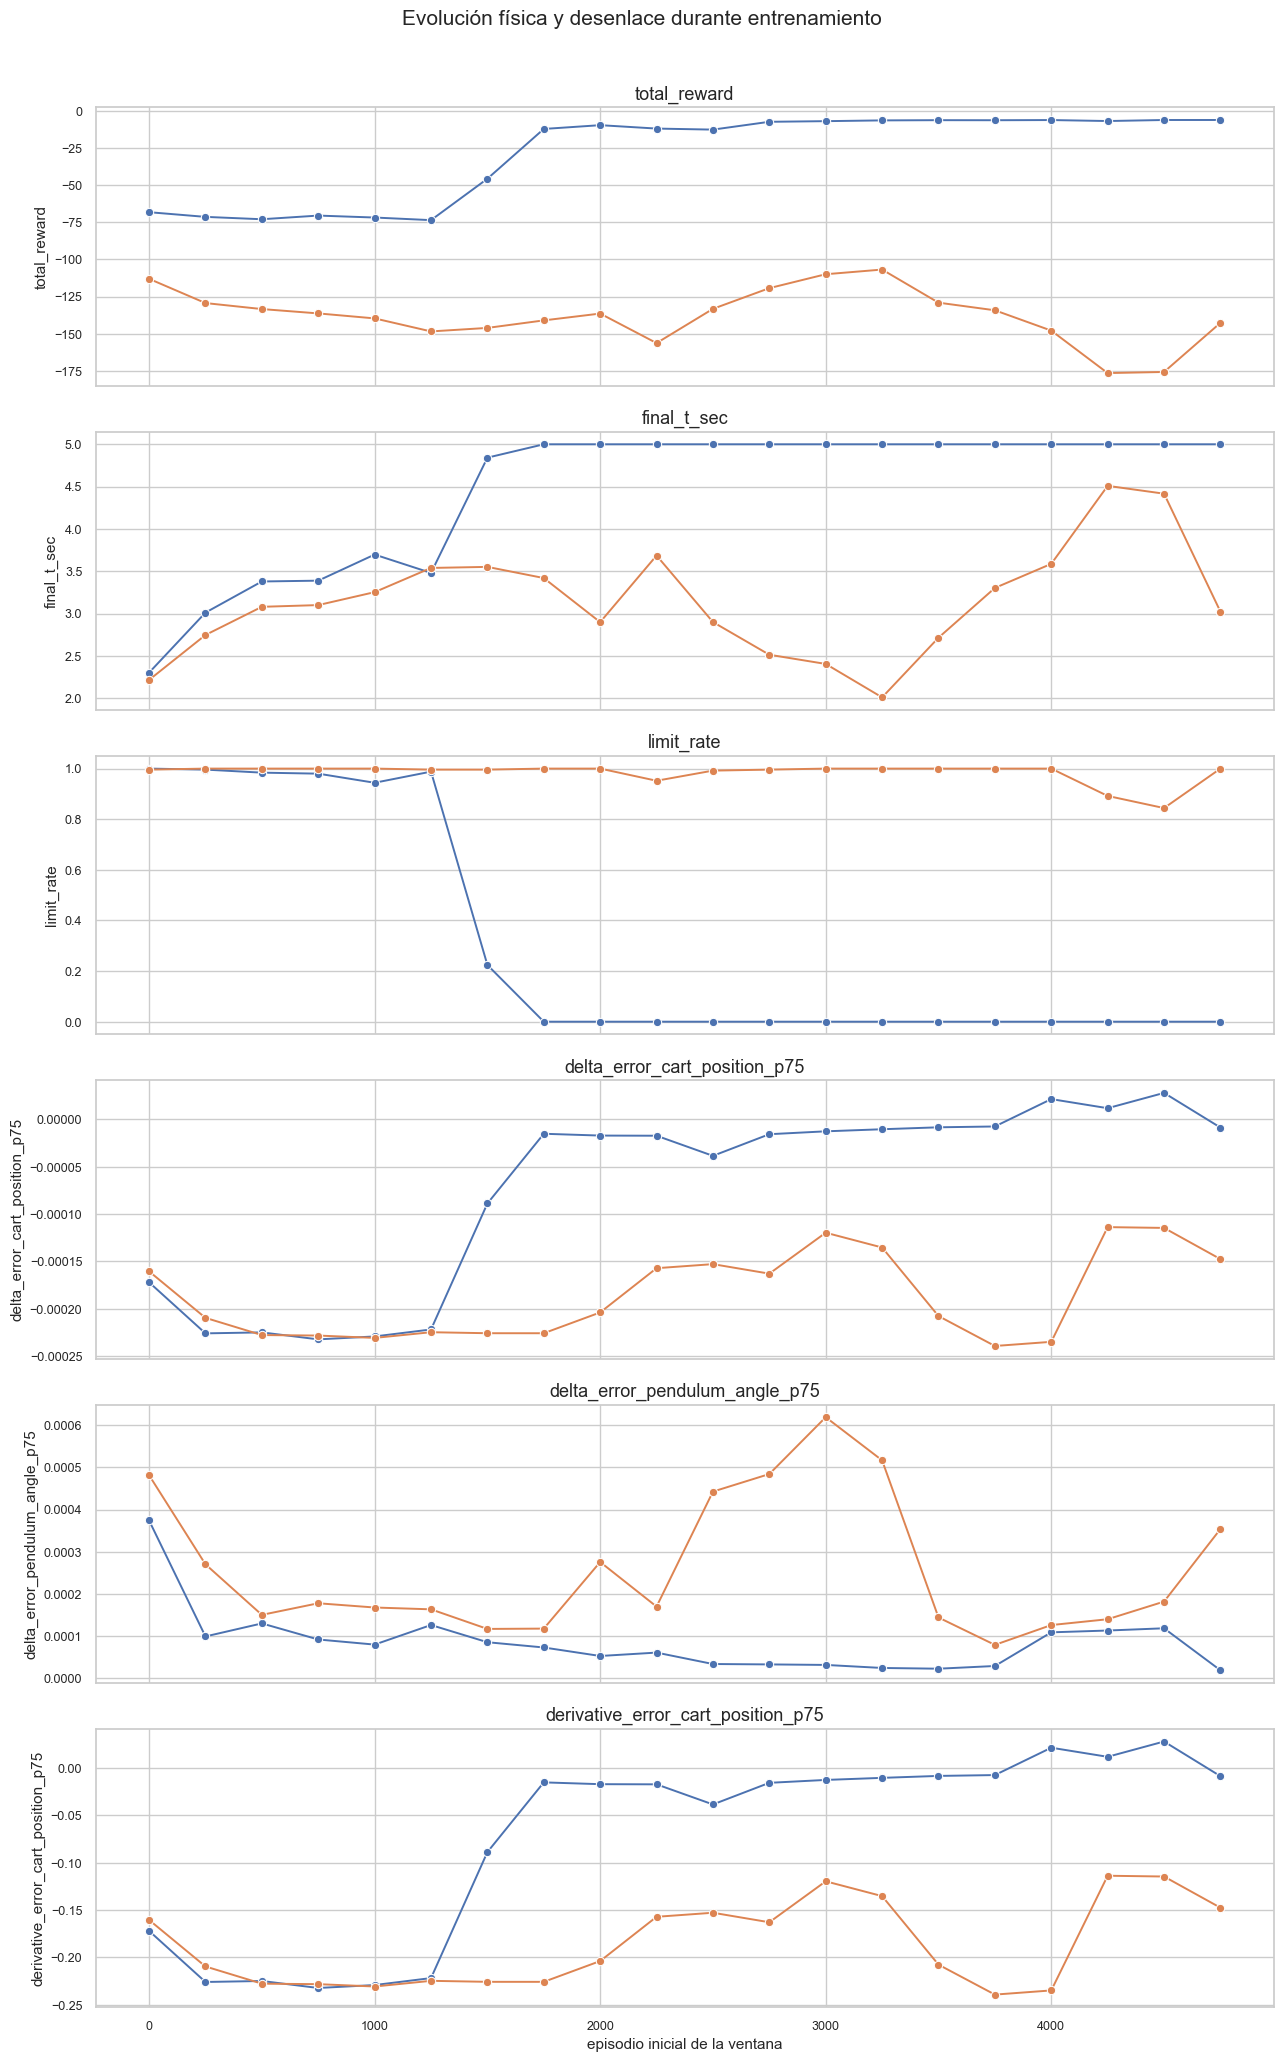

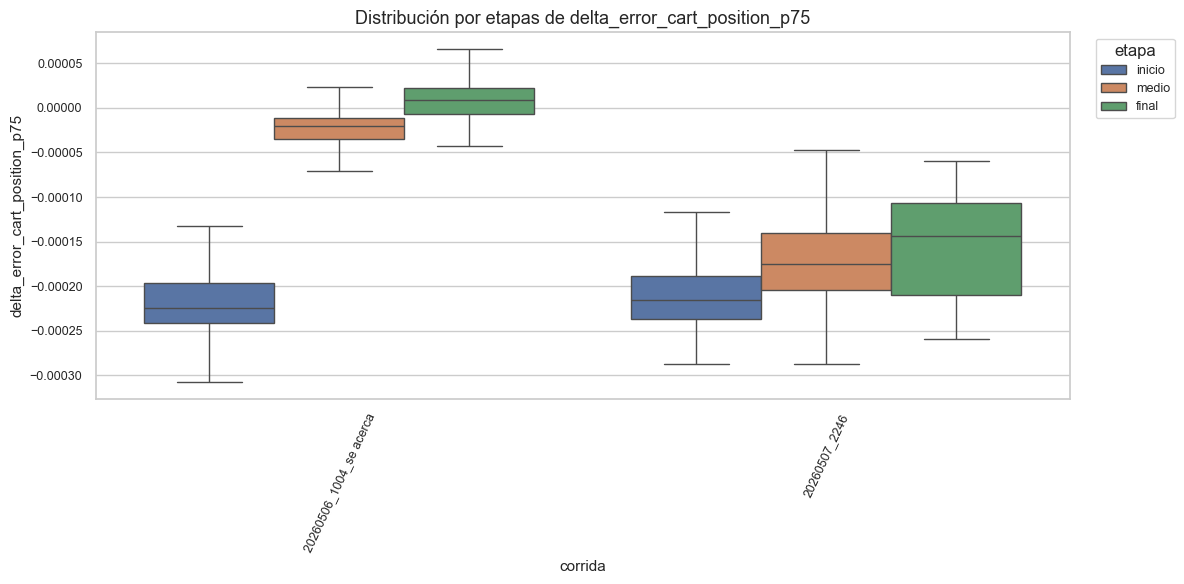

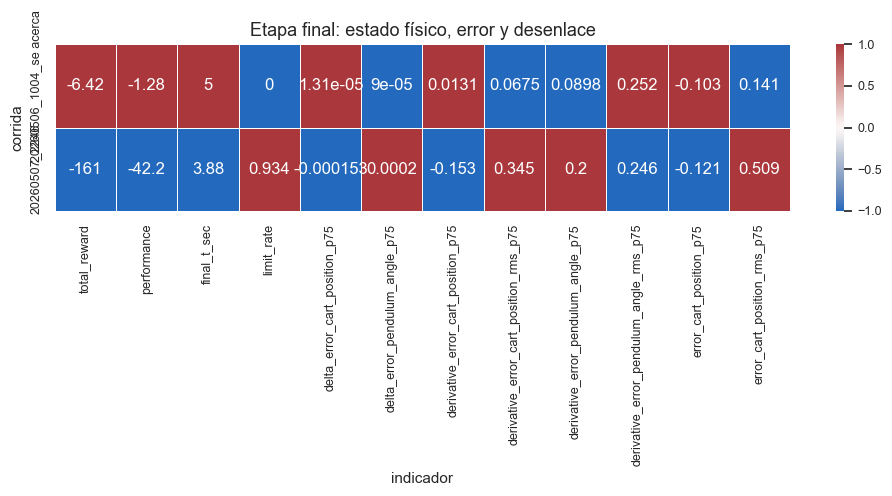

In [6]:
# ----------------------------
# Configuración local de sección 4
# ----------------------------
physical_options = metric_options(summary_dictionary, families=["physical_state", "physical_final_state", "error_dynamics"], variables=ANALYSIS_STATE_VARIABLES)
display(physical_options[["family", "variable", "base_metric", "stat", "column"]].head(120))

PHYSICAL_BASE_SELECTION = choose_base_metrics(
    summary_dictionary,
    families=["error_dynamics", "physical_state"],
    variables=ANALYSIS_STATE_VARIABLES,
    preferred_terms=["error_", "derivative_error_", "_raw", "_norm"],
    max_metrics=12,
)
PHYSICAL_STATS_FOR_PLOTS = ["mean", "p50", "p75"]
PHYSICAL_COLUMNS = columns_from_bases(summary_dictionary, PHYSICAL_BASE_SELECTION, PHYSICAL_STATS_FOR_PLOTS)

RUN_ORDER_METRIC = "total_reward"          # opciones típicas: "total_reward", "performance", "final_t_sec", None
RUN_ORDER_ASCENDING = False
run_order = ordered_run_ids(final_profile, RUN_ORDER_METRIC, ascending=RUN_ORDER_ASCENDING)
RUNS_TO_DRAW = run_order[:min(8, len(run_order))]

physical_window_metrics = [col for col in PHYSICAL_COLUMNS if col in window_table.columns][:8]
fig_physical_evolution = plot_window_lines(
    window_table,
    metrics=["total_reward", "final_t_sec", "limit_rate"] + physical_window_metrics[:3],
    run_ids=RUNS_TO_DRAW,
    title="Evolución física y desenlace durante entrenamiento",
)
plt.show()

if physical_window_metrics:
    fig_physical_distribution = plot_stage_distribution(
        stage_df,
        metric=physical_window_metrics[0],
        run_order=RUNS_TO_DRAW,
        title=f"Distribución por etapas de {physical_window_metrics[0]}",
    )
    plt.show()

fig_physical_heatmap = plot_metric_heatmap(
    final_profile,
    metric_columns=["total_reward", "performance", "final_t_sec", "limit_rate"] + physical_window_metrics,
    run_order=run_order,
    title="Etapa final: estado físico, error y desenlace",
)
plt.show()


## 5. Controlador, esfuerzo y ganancias aprendidas

**Pregunta.** ¿Las acciones y las ganancias PID aprendidas son compatibles con el comportamiento físico observado?

**Qué observar para decidir.**

- Ganancias finales pegadas a límites o con saltos fuertes sugieren que el agente está empujando contra restricciones de diseño.
- Mucho esfuerzo (`u_*`, `control_action_*`, `saturation_*`) con poca mejora física sugiere revisar penalización de esfuerzo, compuertas o normalización de `u`.
- Si una ganancia sube mientras su recompensa por agente baja, puede haber una señal de aprendizaje mal alineada.


,family,variable,base_metric,stat,column
0,control_effort,cart_position,control_action_cart_position,max,control_action_cart_position_max
1,control_effort,cart_position,control_action_cart_position,mean,control_action_cart_position_mean
2,control_effort,cart_position,control_action_cart_position,min,control_action_cart_position_min
3,control_effort,cart_position,control_action_cart_position,p25,control_action_cart_position_p25
4,control_effort,cart_position,control_action_cart_position,p50,control_action_cart_position_p50
...,...,...,...,...,...
135,learning_signal,pendulum_angle,q_value_kp_pendulum_angle,p25,q_value_kp_pendulum_angle_p25
136,learning_signal,pendulum_angle,q_value_kp_pendulum_angle,p50,q_value_kp_pendulum_angle_p50
137,learning_signal,pendulum_angle,q_value_kp_pendulum_angle,p75,q_value_kp_pendulum_angle_p75
138,learning_signal,pendulum_angle,q_value_kp_pendulum_angle,std,q_value_kp_pendulum_angle_std


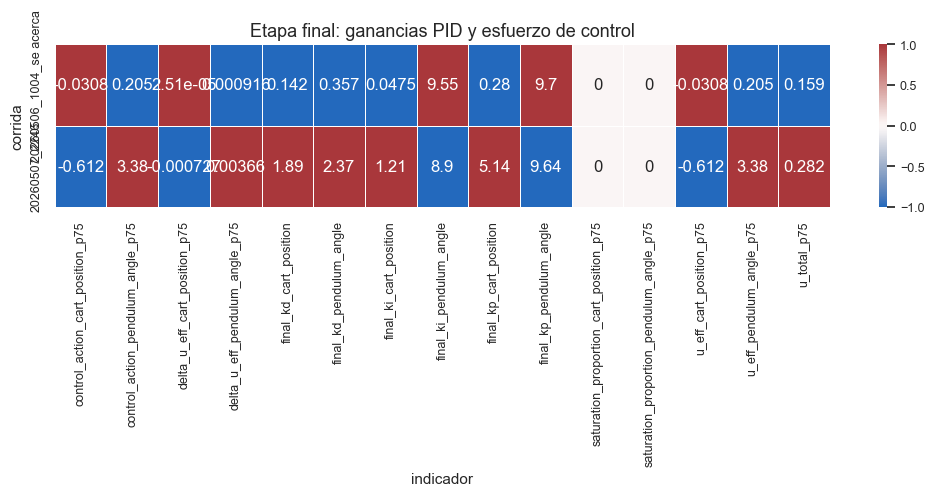

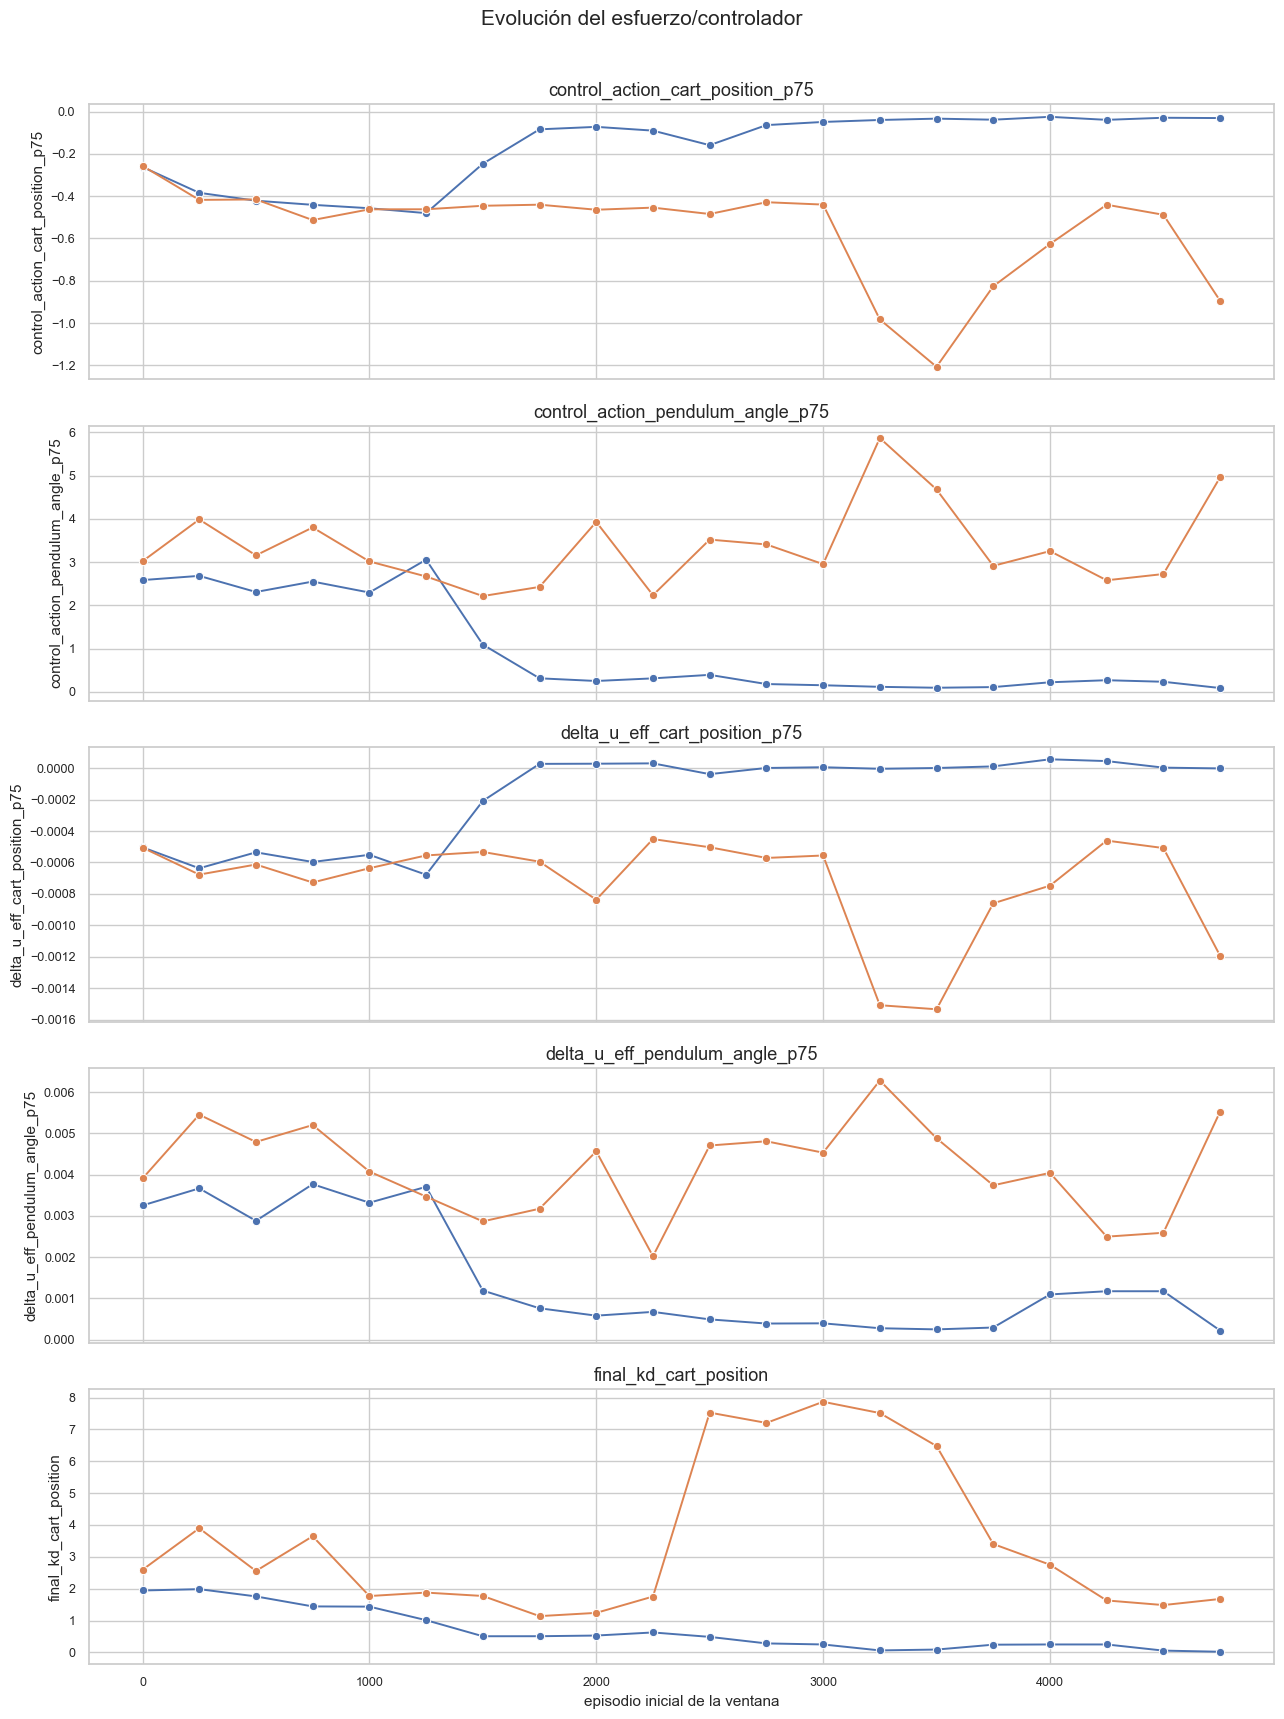

In [7]:
# ----------------------------
# Configuración local de sección 5
# ----------------------------
control_options = metric_options(summary_dictionary, families=["controller_gain", "control_effort", "learning_signal"], variables=ANALYSIS_TARGET_VARIABLES)
display(control_options[["family", "variable", "base_metric", "stat", "column"]].head(140))

CONTROL_BASE_SELECTION = choose_base_metrics(
    summary_dictionary,
    families=["controller_gain", "control_effort"],
    variables=ANALYSIS_TARGET_VARIABLES,
    preferred_terms=["final_", "u_eff", "control_action", "saturation", "u_total"],
    max_metrics=18,
)
CONTROL_COLUMNS = columns_from_bases(summary_dictionary, CONTROL_BASE_SELECTION, ["mean", "p50", "p75", "max"], include_unstat=True)

fig_control_heatmap = plot_metric_heatmap(
    final_profile,
    metric_columns=CONTROL_COLUMNS,
    run_order=run_order,
    title="Etapa final: ganancias PID y esfuerzo de control",
)
plt.show()

control_window_metrics = [col for col in CONTROL_COLUMNS if col in window_table.columns][:5]
if control_window_metrics:
    fig_control_evolution = plot_window_lines(
        window_table,
        metrics=control_window_metrics,
        run_ids=RUNS_TO_DRAW,
        title="Evolución del esfuerzo/controlador",
    )
    plt.show()


## 6. Consistencia de normalización y componentes `L_*`

**Pregunta.** ¿Los `L_e`, `L_edot`, `L_u` y sus compuertas reflejan de forma coherente los errores y esfuerzos observados?

**Qué observar para decidir.**

- Si el error físico cambia pero `L_e` casi no cambia, el rango de normalización puede estar saturando o ser poco sensible.
- Si `L_u` domina sin que exista esfuerzo alto, revise el rango o el escalado de esfuerzo.
- Si una compuerta permanece cerca de cero o de uno durante toda la etapa final, quizá no está modulando: solo bloquea o deja pasar.
- Si los `principal_contribution_*` no siguen el sentido de sus `L_*`, revise pesos, escalados o compuertas.


,family,variable,base_metric,stat,column
0,loss_components,cart_position,L_cart_position,max,L_cart_position_max
1,loss_components,cart_position,L_cart_position,mean,L_cart_position_mean
2,loss_components,cart_position,L_cart_position,min,L_cart_position_min
3,loss_components,cart_position,L_cart_position,p25,L_cart_position_p25
4,loss_components,cart_position,L_cart_position,p50,L_cart_position_p50
...,...,...,...,...,...
121,principal_gates,pendulum_angle,principal_gate_L_u_pendulum_angle,min,principal_gate_L_u_pendulum_angle_min
122,principal_gates,pendulum_angle,principal_gate_L_u_pendulum_angle,p25,principal_gate_L_u_pendulum_angle_p25
123,principal_gates,pendulum_angle,principal_gate_L_u_pendulum_angle,p50,principal_gate_L_u_pendulum_angle_p50
124,principal_gates,pendulum_angle,principal_gate_L_u_pendulum_angle,p75,principal_gate_L_u_pendulum_angle_p75


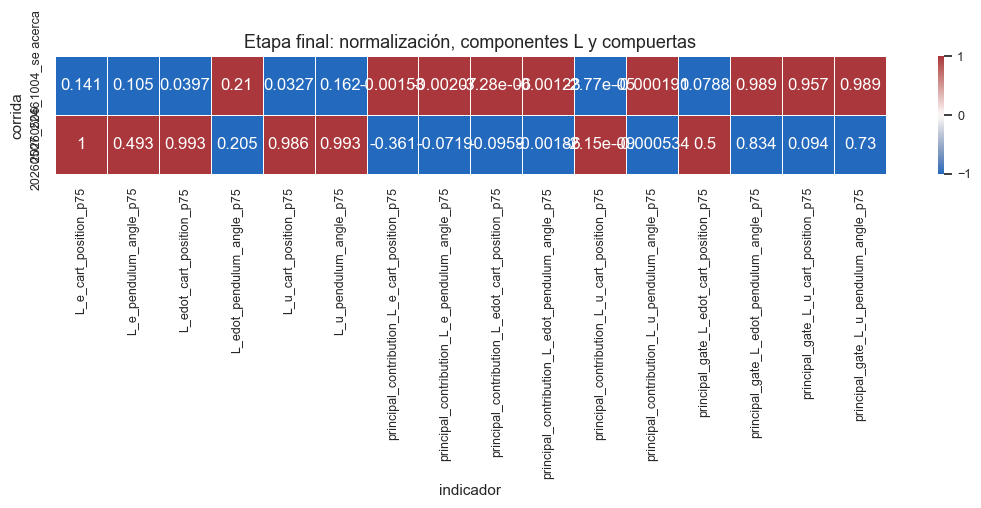

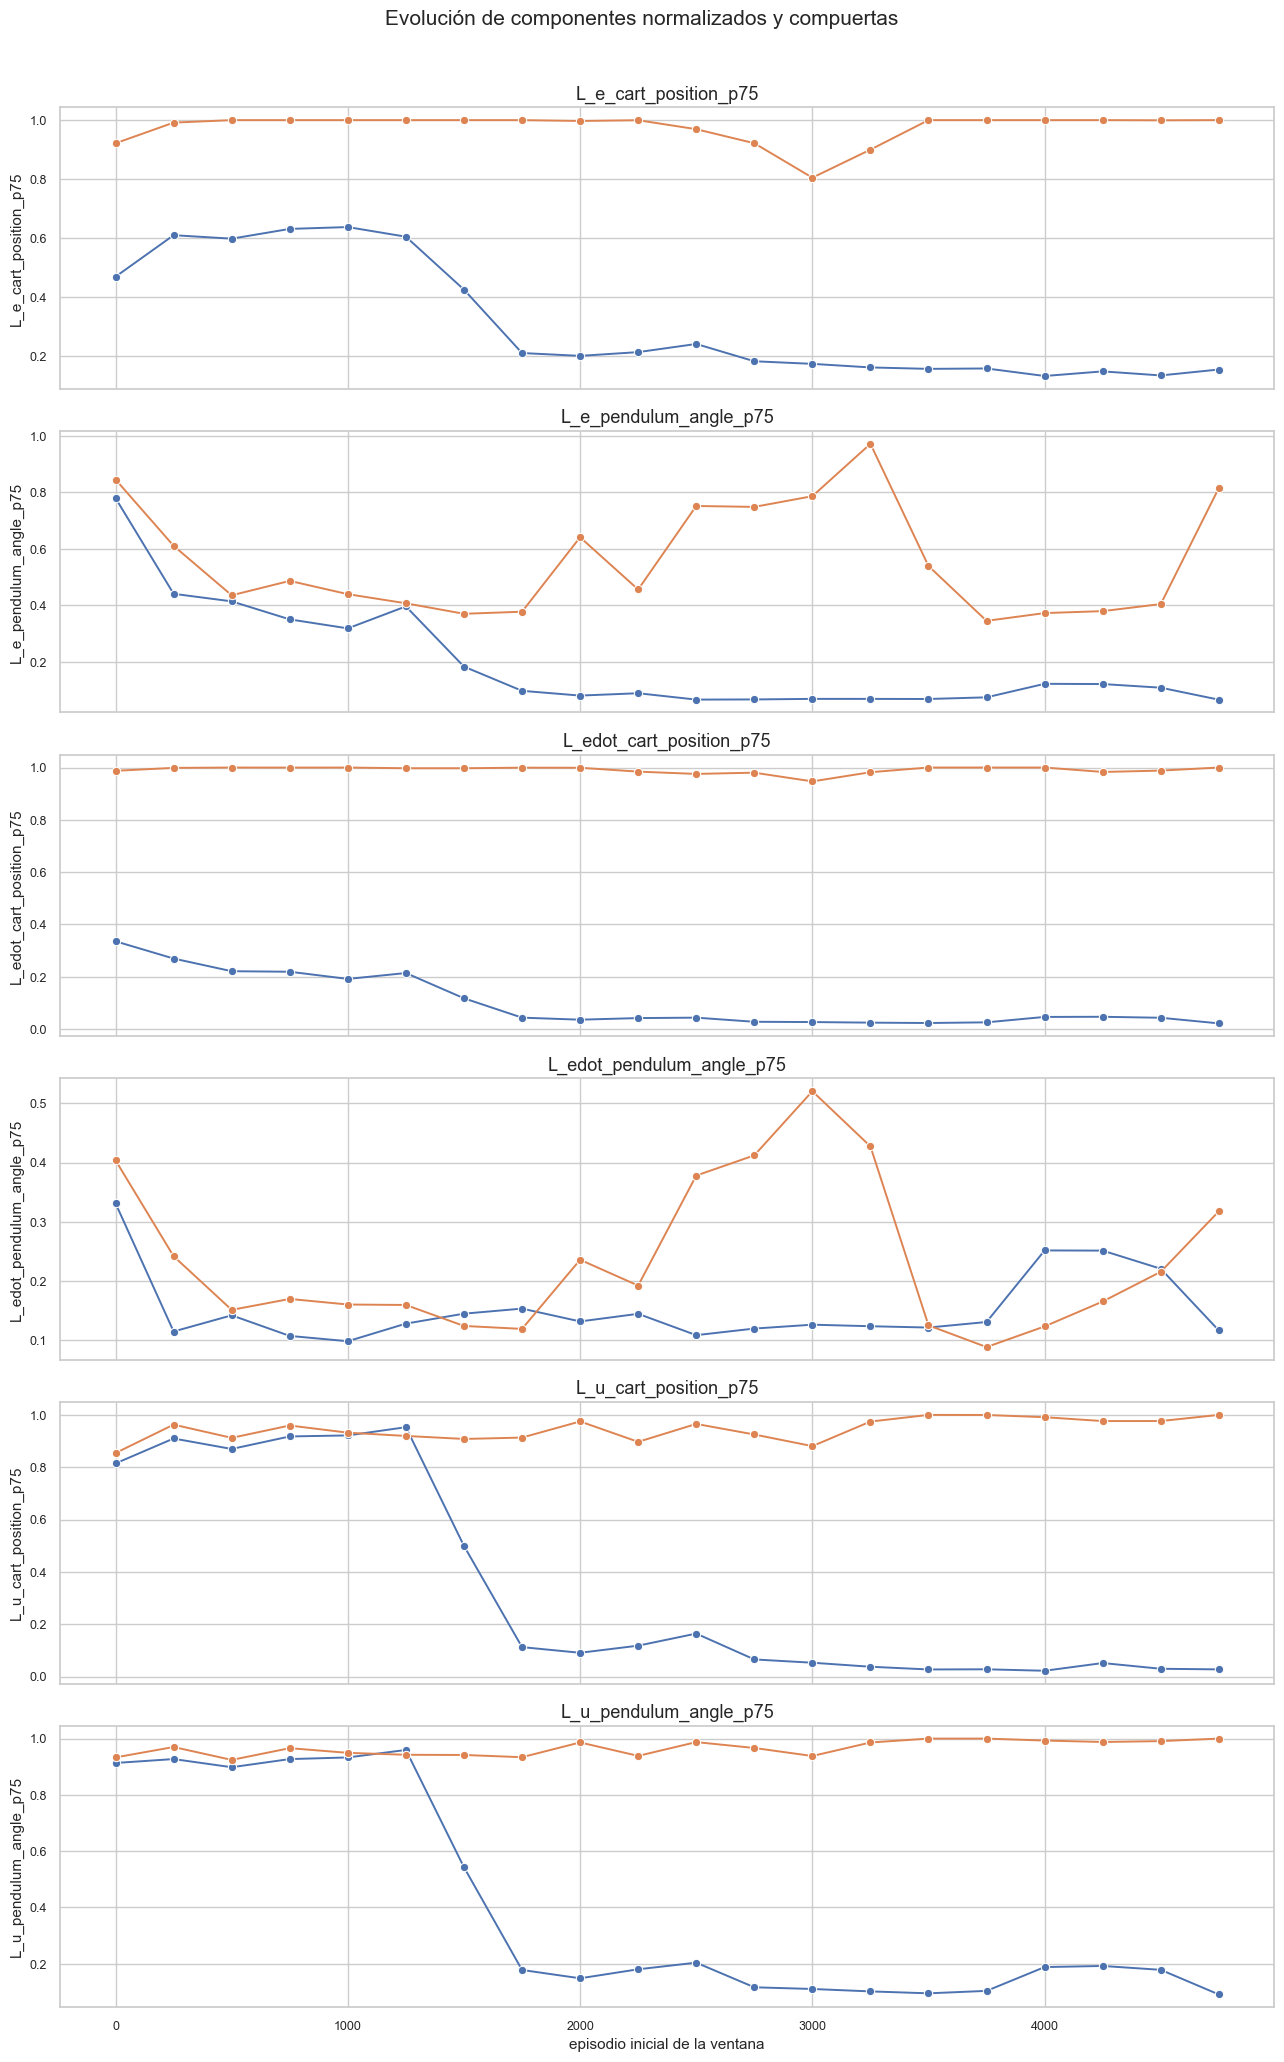

In [8]:
# ----------------------------
# Configuración local de sección 6
# ----------------------------
normalization_options = metric_options(summary_dictionary, families=["loss_components", "principal_gates"], variables=ANALYSIS_TARGET_VARIABLES)
display(normalization_options[["family", "variable", "base_metric", "stat", "column"]].head(160))

L_BASE_SELECTION = choose_base_metrics(
    summary_dictionary,
    families=["loss_components", "principal_gates"],
    variables=ANALYSIS_TARGET_VARIABLES,
    preferred_terms=["L_e", "L_edot", "L_u", "principal_gate", "principal_contribution"],
    max_metrics=20,
)
L_COLUMNS = columns_from_bases(summary_dictionary, L_BASE_SELECTION, ["mean", "p50", "p75", "max"])

fig_l_heatmap = plot_metric_heatmap(
    final_profile,
    metric_columns=L_COLUMNS,
    run_order=run_order,
    title="Etapa final: normalización, componentes L y compuertas",
)
plt.show()

l_window_metrics = [col for col in L_COLUMNS if col in window_table.columns][:6]
if l_window_metrics:
    fig_l_evolution = plot_window_lines(
        window_table,
        metrics=l_window_metrics,
        run_ids=RUNS_TO_DRAW,
        title="Evolución de componentes normalizados y compuertas",
    )
    plt.show()


## 7. Recompensas y señales de aprendizaje

**Pregunta.** ¿La recompensa principal, la coordinativa y las recompensas asignadas a agentes explican el aprendizaje observado?

**Qué observar para decidir.**

- La recompensa total debe leerse junto a `principal_reward`, `coordination_reward_total` y recompensas por agente.
- Una recompensa coordinativa positiva sin mejora física puede estar premiando progreso parcial insuficiente.
- `td_error_*` persistente o muy disperso en etapa final sugiere señal de aprendizaje ruidosa o no estacionaria.
- `q_value_*` que se aplana sin mejora física puede indicar convergencia hacia una política pobre.


,family,variable,base_metric,stat,column
0,coordination,cart_position,coordination_credit_raw_cart_position,max,coordination_credit_raw_cart_position_max
1,coordination,cart_position,coordination_credit_raw_cart_position,mean,coordination_credit_raw_cart_position_mean
2,coordination,cart_position,coordination_credit_raw_cart_position,min,coordination_credit_raw_cart_position_min
3,coordination,cart_position,coordination_credit_raw_cart_position,p25,coordination_credit_raw_cart_position_p25
4,coordination,cart_position,coordination_credit_raw_cart_position,p50,coordination_credit_raw_cart_position_p50
...,...,...,...,...,...
175,reward_components,pendulum_angle,reward_kd_pendulum_angle,max,reward_kd_pendulum_angle_max
176,reward_components,pendulum_angle,reward_kd_pendulum_angle,mean,reward_kd_pendulum_angle_mean
177,reward_components,pendulum_angle,reward_kd_pendulum_angle,min,reward_kd_pendulum_angle_min
178,reward_components,pendulum_angle,reward_kd_pendulum_angle,p25,reward_kd_pendulum_angle_p25


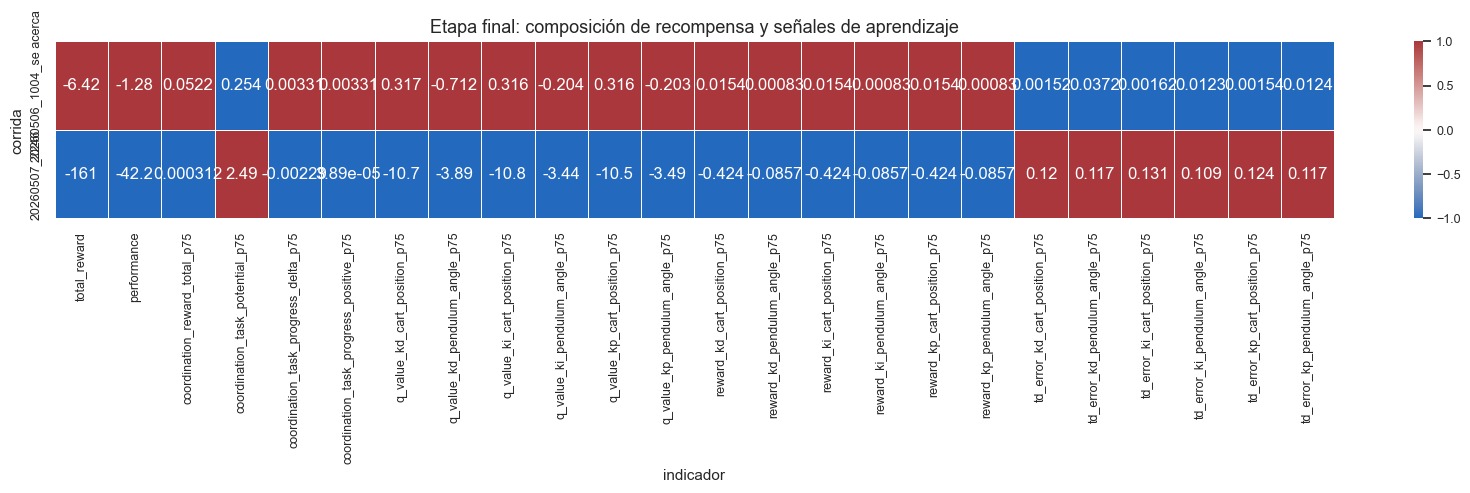

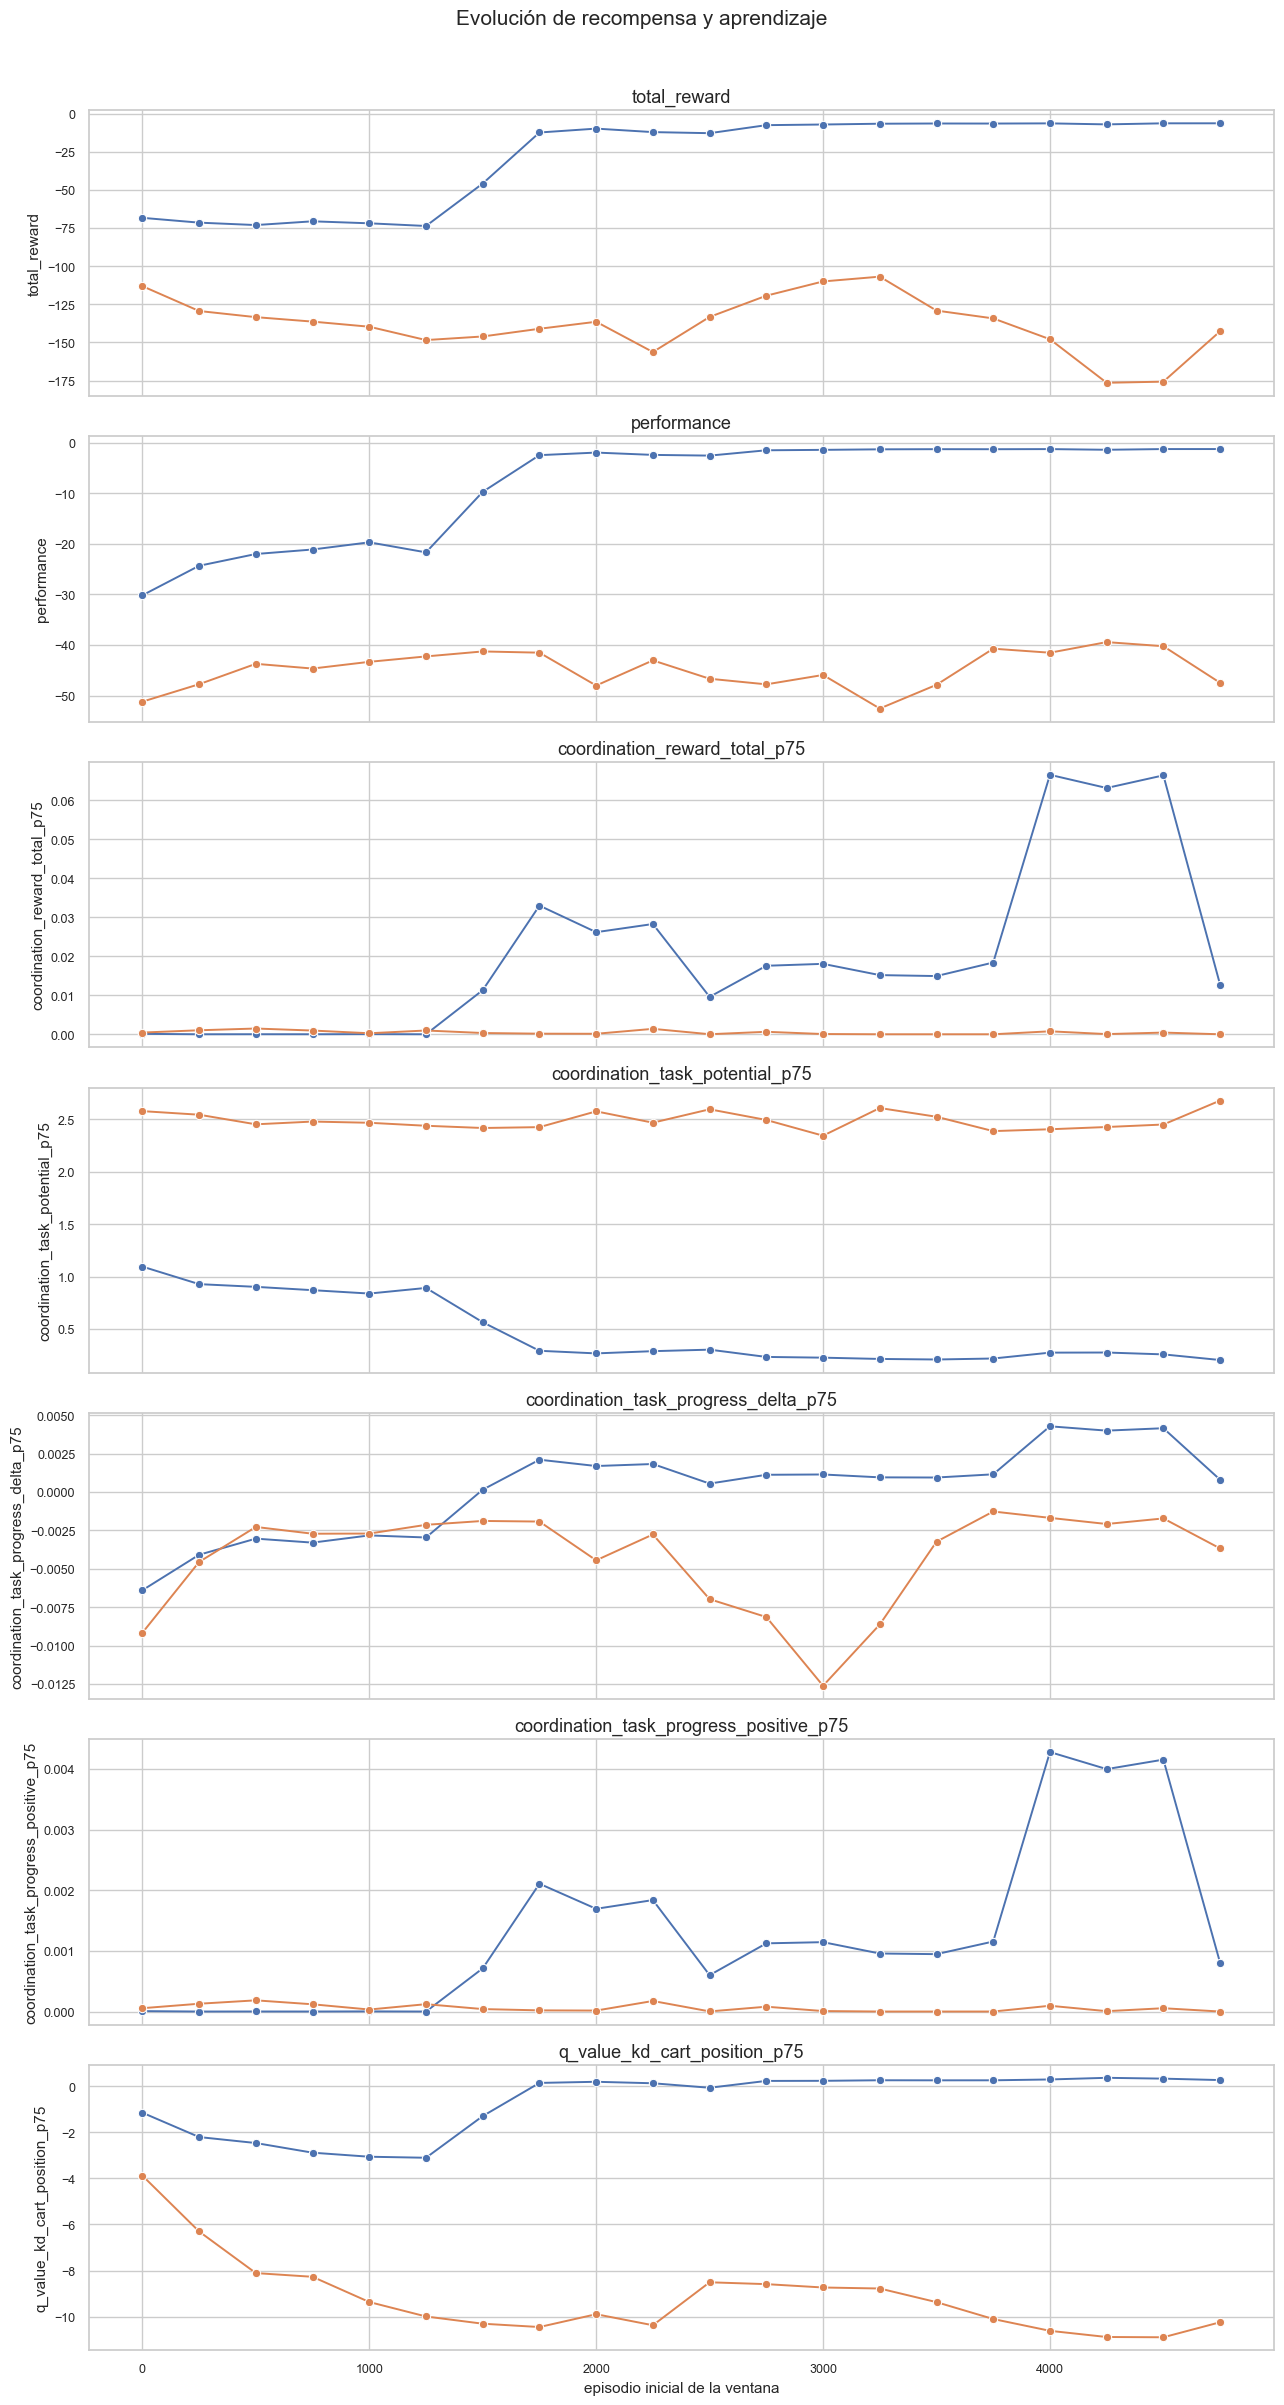

In [9]:
# ----------------------------
# Configuración local de sección 7
# ----------------------------
reward_options = metric_options(summary_dictionary, families=["reward_components", "coordination", "learning_signal"], variables=ANALYSIS_TARGET_VARIABLES)
display(reward_options[["family", "variable", "base_metric", "stat", "column"]].head(180))

REWARD_BASE_SELECTION = choose_base_metrics(
    summary_dictionary,
    families=["reward_components", "coordination", "learning_signal"],
    variables=ANALYSIS_TARGET_VARIABLES,
    preferred_terms=["principal_reward", "coordination_reward", "coordination_task", "reward_", "td_error", "q_value"],
    max_metrics=22,
)
REWARD_COLUMNS = columns_from_bases(summary_dictionary, REWARD_BASE_SELECTION, ["mean", "p50", "p75", "max"])

fig_reward_heatmap = plot_metric_heatmap(
    final_profile,
    metric_columns=["total_reward", "performance"] + REWARD_COLUMNS,
    run_order=run_order,
    title="Etapa final: composición de recompensa y señales de aprendizaje",
)
plt.show()

reward_window_metrics = [col for col in ["total_reward", "performance"] + REWARD_COLUMNS if col in window_table.columns][:7]
fig_reward_evolution = plot_window_lines(
    window_table,
    metrics=reward_window_metrics,
    run_ids=RUNS_TO_DRAW,
    title="Evolución de recompensa y aprendizaje",
)
plt.show()


## 8. Integración con parámetros de metadata

**Pregunta.** ¿Qué parámetros de configuración se asocian con los patrones observados en summary?

**Cómo usar esta sección.**

- Primero seleccione familias de metadata. Para reward design normalmente conviene comenzar por normalización, pesos principales, compuertas y coordinación.
- Luego seleccione indicadores de summary que ya hayan mostrado diferencias relevantes en las secciones anteriores.
- La correlación Spearman solo ordena relaciones monotónicas entre corridas; no debe leerse como causalidad. Su valor está en señalar qué parámetros conviene inspeccionar primero.


,family,selected_label,n_unique,values_preview,param_path
0,coordination,coord.global_weight,2,"16, 8",config_main.reward_base.reward_calculation.coo...
1,coordination,coord.potential_weights.L_e.cart_position,2,"1.0, 1.5",config_main.reward_base.reward_calculation.coo...
2,coordination,coord.potential_weights.L_e.pendulum_angle,2,"0.5, 0.4",config_main.reward_base.reward_calculation.coo...
3,coordination,coord.potential_weights.L_edot.cart_position,2,"0.5, 0.8",config_main.reward_base.reward_calculation.coo...
4,coordination,coord.potential_weights.L_edot.pendulum_angle,2,"0.3, 0.2",config_main.reward_base.reward_calculation.coo...
5,coordination,coord.progress_clip_max,2,"0.04, 0.02",config_main.reward_base.reward_calculation.coo...
6,normalization,norm.cart_position.I.range[0],2,"-2.0, -0.7",config_main.reward_base.reward_calculation.met...
7,normalization,norm.cart_position.I.range[1],2,"2.0, 0.7",config_main.reward_base.reward_calculation.met...
8,normalization,norm.cart_position.e.range[0],2,"-1.0, -0.3",config_main.reward_base.reward_calculation.met...
9,normalization,norm.cart_position.e.range[1],2,"1.0, 0.3",config_main.reward_base.reward_calculation.met...


,result_metric_options_used
0,total_reward
1,performance
2,final_t_sec
3,limit_rate
4,delta_error_cart_position_p75
5,delta_error_pendulum_angle_p75
6,derivative_error_cart_position_p75
7,derivative_error_cart_position_rms_p75
8,derivative_error_pendulum_angle_p75
9,derivative_error_pendulum_angle_rms_p75


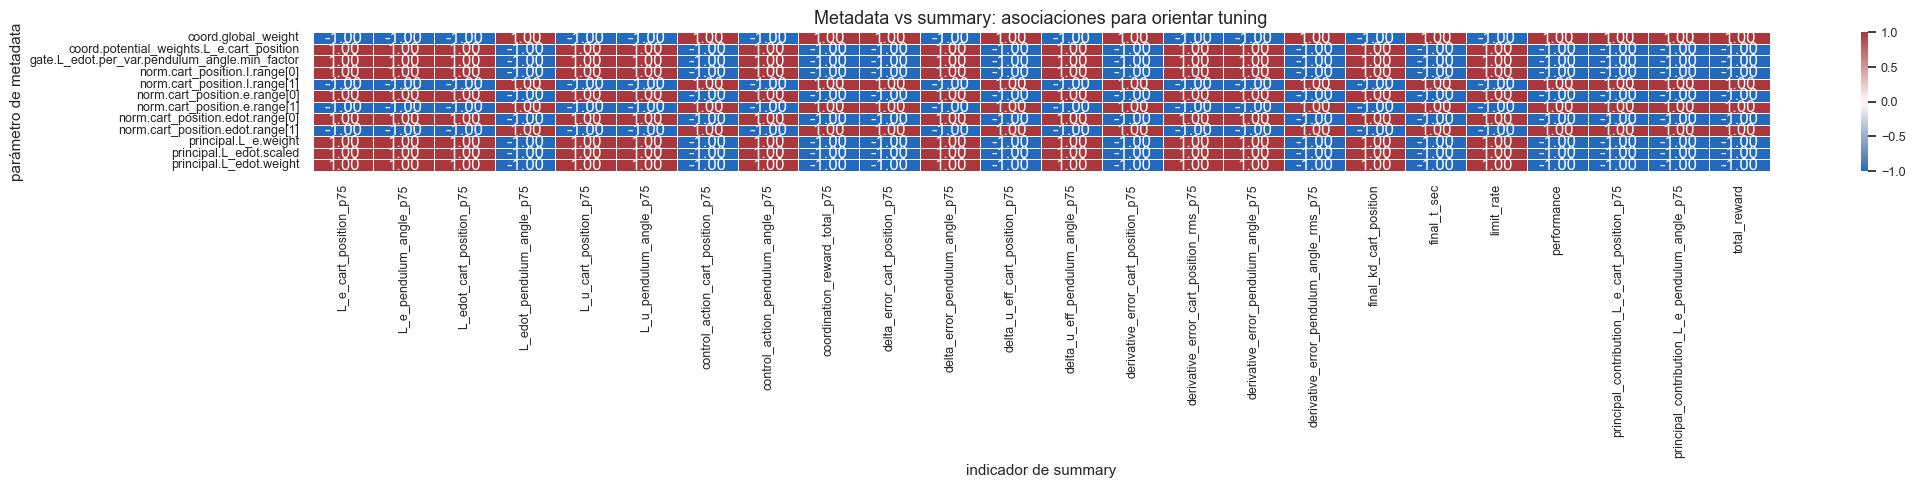

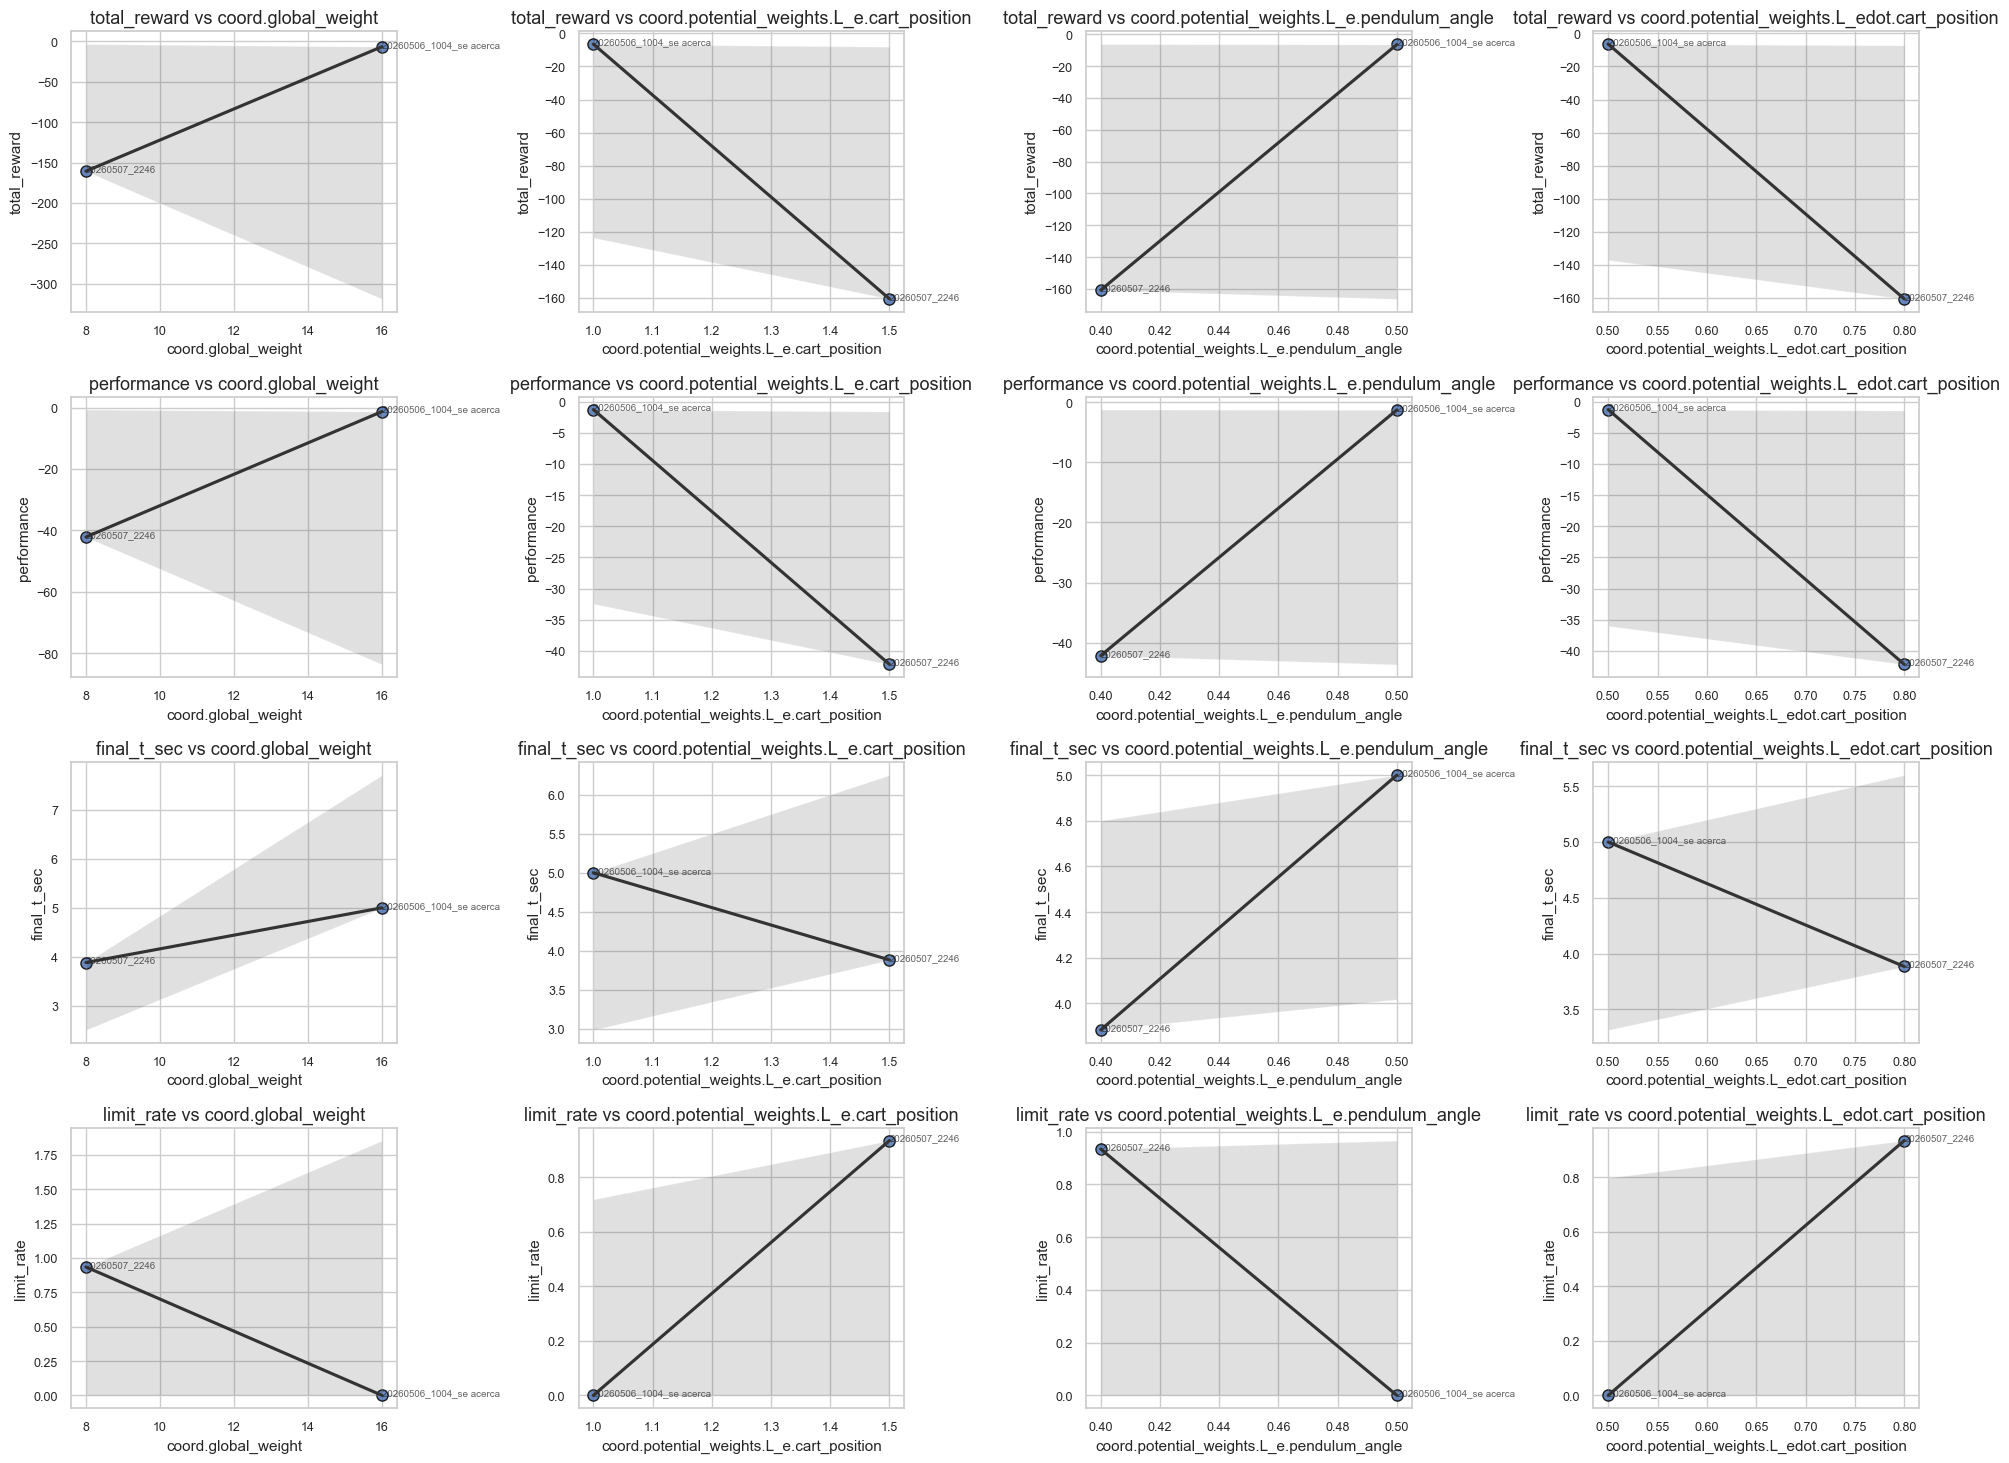

In [10]:
# ----------------------------
# Configuración local de sección 8
# ----------------------------
METADATA_FAMILIES_FOR_ANALYSIS = ["principal_features", "principal_gates", "coordination", "normalization", "agent_learning"]
MAX_METADATA_PARAMETERS = 24

parameter_values, selected_parameter_table = parameter_value_table(
    metadata_table,
    metadata_dict,
    families=METADATA_FAMILIES_FOR_ANALYSIS,
    only_variant=True,
    only_numeric=True,
    max_parameters=MAX_METADATA_PARAMETERS,
)

candidate_result_metrics = [
    "total_reward", "performance", "final_t_sec", "limit_rate",
    *[col for col in PHYSICAL_COLUMNS if col in final_profile.columns][:6],
    *[col for col in CONTROL_COLUMNS if col in final_profile.columns][:5],
    *[col for col in L_COLUMNS if col in final_profile.columns][:8],
    *[col for col in REWARD_COLUMNS if col in final_profile.columns][:8],
]
RESULT_METRICS_FOR_METADATA = list(dict.fromkeys([col for col in candidate_result_metrics if col in final_profile.columns]))[:24]
PARAMETERS_FOR_SCATTER = [col for col in parameter_values.columns if col != "run_id"][:4]
METRICS_FOR_SCATTER = RESULT_METRICS_FOR_METADATA[:4]

display(selected_parameter_table[["family", "selected_label", "n_unique", "values_preview", "param_path"]])
display(pd.DataFrame({"result_metric_options_used": RESULT_METRICS_FOR_METADATA}))

parameter_metric_corr = corr_table(
    left_df=parameter_values,
    right_df=final_profile,
    left_key="run_id",
    right_key="run_id",
    left_columns=[col for col in parameter_values.columns if col != "run_id"],
    right_columns=RESULT_METRICS_FOR_METADATA,
    method="spearman",
)

fig_param_corr = plot_parameter_metric_heatmap(
    parameter_metric_corr,
    max_parameters=12,
    title="Metadata vs summary: asociaciones para orientar tuning",
)
plt.show()

if PARAMETERS_FOR_SCATTER and METRICS_FOR_SCATTER:
    fig_param_scatter = plot_parameter_scatter_grid(final_profile, parameter_values, PARAMETERS_FOR_SCATTER, METRICS_FOR_SCATTER)
    plt.show()


## 9. Secuencia final mínima de gráficos para comparar simulaciones

**Propósito.** Reunir la evidencia suficiente con pocos paneles. Esta secuencia no decide por el usuario; deja visibles las relaciones que deben sostener el criterio de decisión.

**Lectura recomendada.**

1. **Evolución:** revise si la mejora aparece durante el entrenamiento o solo en la ventana final.
2. **Física y control:** confirme que reward, error, duración y esfuerzo no se contradicen.
3. **Normalización y reward:** revise si `L_*`, compuertas y recompensas explican lo observado.
4. **Metadata:** identifique qué parámetros cambian junto con los indicadores relevantes.


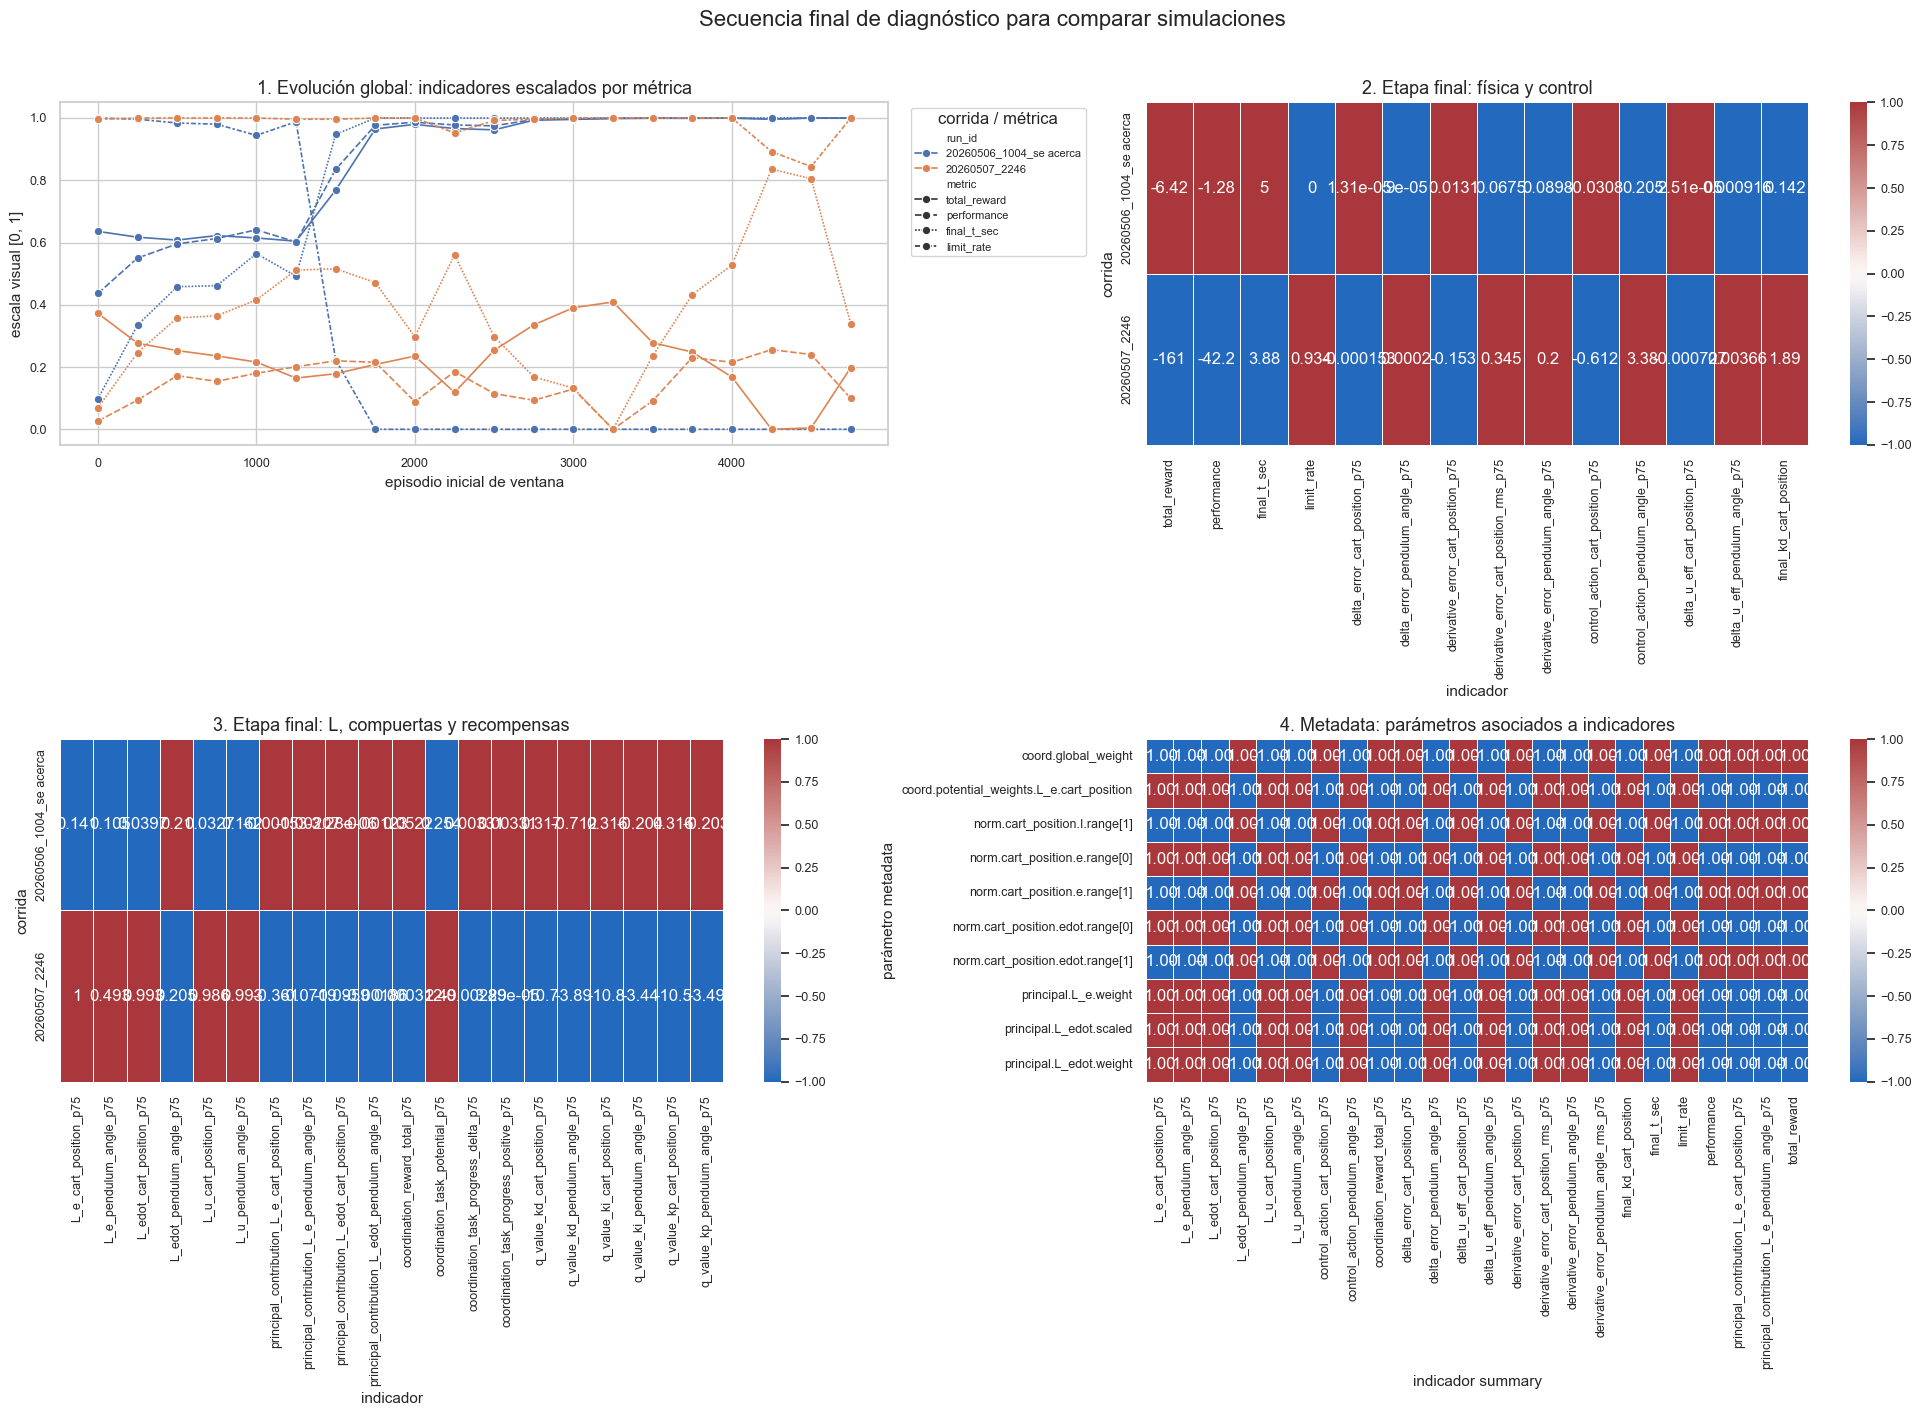

Figura final guardada en: C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5_SimpleSystemSimulator\analysis\summary_reward_metadata_outputs\summary_metadata_final_diagnostic_sequence.png


In [11]:
# ----------------------------
# Configuración local de sección 9
# ----------------------------
FINAL_OUTPUT_DIR = PROJECT_ROOT / "analysis" / "summary_reward_metadata_outputs"
FINAL_FIGURE_NAME = "summary_metadata_final_diagnostic_sequence.png"

FINAL_EVOLUTION_METRICS = ["total_reward", "performance", "final_t_sec", "limit_rate"]
FINAL_PHYSICAL_CONTROL_METRICS = list(dict.fromkeys(
    ["total_reward", "performance", "final_t_sec", "limit_rate"] +
    [col for col in PHYSICAL_COLUMNS if col in final_profile.columns][:5] +
    [col for col in CONTROL_COLUMNS if col in final_profile.columns][:5]
))
FINAL_REWARD_L_METRICS = list(dict.fromkeys(
    [col for col in L_COLUMNS if col in final_profile.columns][:10] +
    [col for col in REWARD_COLUMNS if col in final_profile.columns][:10]
))

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

plt.sca(axes[0, 0])
data_evo = window_table[window_table["run_id"].isin(RUNS_TO_DRAW)]
evo_metrics = [m for m in FINAL_EVOLUTION_METRICS if m in window_table.columns]
evo_long = data_evo.melt(id_vars=["run_id", "episode_window"], value_vars=evo_metrics, var_name="metric", value_name="raw_value")
evo_long["raw_value"] = pd.to_numeric(evo_long["raw_value"], errors="coerce")
evo_long["scaled_value"] = evo_long.groupby("metric")["raw_value"].transform(minmax_by_group)
sns.lineplot(
    data=evo_long,
    x="episode_window",
    y="scaled_value",
    hue="run_id",
    style="metric",
    marker="o",
    linewidth=1.2,
    ax=axes[0, 0],
)
axes[0, 0].set_title("1. Evolución global: indicadores escalados por métrica")
axes[0, 0].set_xlabel("episodio inicial de ventana")
axes[0, 0].set_ylabel("escala visual [0, 1]")
axes[0, 0].legend(title="corrida / métrica", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

heat_pc = final_profile.set_index("run_id").loc[run_order, FINAL_PHYSICAL_CONTROL_METRICS].apply(pd.to_numeric, errors="coerce")
shown_pc = normalize_for_heatmap(heat_pc.reset_index(), FINAL_PHYSICAL_CONTROL_METRICS).set_index(heat_pc.index)
sns.heatmap(shown_pc, cmap="vlag", center=0, annot=heat_pc, fmt=".3g", linewidths=0.4, ax=axes[0, 1])
axes[0, 1].set_title("2. Etapa final: física y control")
axes[0, 1].set_xlabel("indicador")
axes[0, 1].set_ylabel("corrida")

heat_rl = final_profile.set_index("run_id").loc[run_order, FINAL_REWARD_L_METRICS].apply(pd.to_numeric, errors="coerce")
shown_rl = normalize_for_heatmap(heat_rl.reset_index(), FINAL_REWARD_L_METRICS).set_index(heat_rl.index)
sns.heatmap(shown_rl, cmap="vlag", center=0, annot=heat_rl, fmt=".3g", linewidths=0.4, ax=axes[1, 0])
axes[1, 0].set_title("3. Etapa final: L, compuertas y recompensas")
axes[1, 0].set_xlabel("indicador")
axes[1, 0].set_ylabel("corrida")

top_corr = parameter_metric_corr.dropna(subset=["correlation"]).assign(abs_corr=lambda df: df["correlation"].abs())
top_params = top_corr.groupby("parameter")["abs_corr"].max().sort_values(ascending=False).head(10).index.tolist()
matrix = top_corr[top_corr["parameter"].isin(top_params)].pivot(index="parameter", columns="metric", values="correlation")
sns.heatmap(matrix, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.4, ax=axes[1, 1])
axes[1, 1].set_title("4. Metadata: parámetros asociados a indicadores")
axes[1, 1].set_xlabel("indicador summary")
axes[1, 1].set_ylabel("parámetro metadata")

fig.suptitle("Secuencia final de diagnóstico para comparar simulaciones", y=1.01, fontsize=16)
fig.tight_layout()

FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
final_figure_path = FINAL_OUTPUT_DIR / FINAL_FIGURE_NAME
fig.savefig(final_figure_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Figura final guardada en: {final_figure_path}")


## 10. Exportación de tablas de trabajo

**Propósito.** Dejar las tablas clave listas para revisar fuera del notebook: diccionario de señales, parámetros variantes, perfiles por etapa, indicadores de etapa final y correlaciones metadata-summary.

Estas tablas son parte del resultado científico del análisis: permiten rastrear de dónde salió cada gráfico y repetir la comparación cuando agregues nuevas simulaciones.


In [12]:
# ----------------------------
# Configuración local de sección 10
# ----------------------------
EXPORT_TABLES = True
EXPORT_DIR = PROJECT_ROOT / "analysis" / "summary_reward_metadata_outputs"

tables_to_export = {
    "run_catalog": run_catalog,
    "selected_catalog": selected_catalog,
    "summary_dictionary": summary_dictionary,
    "metadata_inventory": metadata_dict,
    "selected_metadata": selected_parameter_table,
    "load_manifest": load_manifest,
    "stage_summary": stage_summary,
    "final_profile": final_profile,
    "parameter_values": parameter_values,
    "parameter_metric_corr": parameter_metric_corr,
}

if EXPORT_TABLES:
    tables_xlsx_path = export_tables(EXPORT_DIR, tables_to_export, "summary_metadata_diagnostic_tables.xlsx")
    print(f"Tablas exportadas en: {tables_xlsx_path}")
else:
    tables_xlsx_path = None


Tablas exportadas en: C:\Users\davor\Escritorio\DOCTORADO\Tesis\RL_5_SimpleSystemSimulator\analysis\summary_reward_metadata_outputs\summary_metadata_diagnostic_tables.xlsx


## Cierre metodológico

La utilidad del `summary.xlsx` está en permitir una lectura por capas. Primero se decide si el entrenamiento produjo una evolución física aceptable. Luego se verifica si el controlador y sus ganancias explican esa evolución. Después se audita si los componentes normalizados `L_*`, las compuertas y las recompensas están representando correctamente lo que se observa en el sistema. Solo entonces se miran los parámetros de metadata para proponer ajustes.

La pregunta final no es "qué corrida tiene más recompensa", sino "qué configuración produce una trayectoria físicamente consistente, controlable y explicable por sus componentes de recompensa". Esa es la base más sólida para mejorar el diseño de parámetros.
